In [ ]:
# @title Import Libraries & Dataset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from google.colab import drive
drive.mount('/content/drive')

# To ignore warnings
import warnings
warnings.simplefilter(action="ignore")

Mounted at /content/drive


# **02-01(Introduction)**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/PlayGolf?/archive/golf_dataset_mini_unprocessed.csv')
df

,Outlook,Temperature,Humidity,Wind,Play
0,sunny,85.0,85.0,0,0
1,sunny,NaN,90.0,1,0
2,overcast,83.0,78.0,0,1
3,rain,70.0,96.0,0,1
4,rain,68.0,80.0,0,1
5,rain,65.0,70.0,1,0
6,overcast,64.0,65.0,1,1
7,sunny,72.0,95.0,0,0
8,sunny,69.0,70.0,0,1
9,rain,75.0,10.0,0,1


In [ ]:
# Remove rows where 'Outlook' is empty
df = df[df['Outlook'].notna()]

# Impute missing values in 'Temperature' with the average
df['Temperature'].fillna(df['Temperature'].mean(), inplace=True)

df[['Outlook','Temperature']]

,Outlook,Temperature
0,sunny,85.00
1,sunny,73.25
2,overcast,83.00
3,rain,70.00
4,rain,68.00
5,rain,65.00
6,overcast,64.00
7,sunny,72.00
8,sunny,69.00
9,rain,75.00


In [ ]:
# Calculate z-scores for 'Humidity'
df['Humidity_zscore'] = zscore(df.loc[:,'Humidity'])

# Identify outliers
outliers = df[np.abs(df['Humidity_zscore']) > 3]

# Replace outliers with the average 'Humidity' for the respective 'Outlook'
for index, row in outliers.iterrows():
    outlook = row['Outlook']
    avg_humidity_for_outlook = df[df['Outlook'] == outlook]['Humidity'].mean()
    df.loc[index, 'Humidity'] = avg_humidity_for_outlook

# Drop the 'Humidity_zscore' column as it's no longer needed
df.drop(['Humidity_zscore'], axis=1, inplace=True)

df[['Humidity']]

,Humidity
0,85.0
1,90.0
2,78.0
3,96.0
4,80.0
5,70.0
6,65.0
7,95.0
8,70.0
9,64.0


In [ ]:
# Loading the Air Quality Index Dataset
aqi_dataset = pd.read_csv("/content/drive/MyDrive/PlayGolf?/archive/L02_DataPreprocessing/golf_dataset_mini_dirty.csv")

# Combining with the DataFrame
df = pd.concat([df,aqi_dataset], axis=1).dropna()

df

,Outlook,Temperature,Humidity,Wind,Play,AirQualityIndex
0,sunny,85.00,85.0,0.0,0.0,85.0
1,sunny,73.25,90.0,1.0,0.0,85.0
2,overcast,83.00,78.0,0.0,1.0,80.5
3,rain,70.00,96.0,0.0,1.0,83.0
4,rain,68.00,80.0,0.0,1.0,74.0
5,rain,65.00,70.0,1.0,0.0,67.5
6,overcast,64.00,65.0,1.0,1.0,64.5
7,sunny,72.00,95.0,0.0,0.0,83.5
8,sunny,69.00,70.0,0.0,1.0,69.5
9,rain,75.00,64.0,0.0,1.0,77.5


In [ ]:
# Generate dummy variables for 'Outlook'
dummies = pd.get_dummies(df['Outlook'], prefix='Outlook').astype(int)

# Append the dummy variables
df = pd.concat([df, dummies], axis=1)

df

,Outlook,Temperature,Humidity,Wind,Play,AirQualityIndex,Outlook_overcast,Outlook_rain,Outlook_sunny
0,sunny,85.00,85.0,0.0,0.0,85.0,0,0,1
1,sunny,73.25,90.0,1.0,0.0,85.0,0,0,1
2,overcast,83.00,78.0,0.0,1.0,80.5,1,0,0
3,rain,70.00,96.0,0.0,1.0,83.0,0,1,0
4,rain,68.00,80.0,0.0,1.0,74.0,0,1,0
5,rain,65.00,70.0,1.0,0.0,67.5,0,1,0
6,overcast,64.00,65.0,1.0,1.0,64.5,1,0,0
7,sunny,72.00,95.0,0.0,0.0,83.5,0,0,1
8,sunny,69.00,70.0,0.0,1.0,69.5,0,0,1
9,rain,75.00,64.0,0.0,1.0,77.5,0,1,0


In [ ]:
# Define bins and labels
bins = [0, 75, 85, 100]  # You can adjust these based on your specific requirements
labels = ['Low', 'Medium', 'High']

# Create a new column with binned 'Humidity'
df['Humidity_Binned'] = pd.cut(df['Humidity'], bins=bins, labels=labels, right=True)

df[['Humidity','Humidity_Binned']]

,Humidity,Humidity_Binned
0,85.0,Medium
1,90.0,High
2,78.0,Medium
3,96.0,High
4,80.0,Medium
5,70.0,Low
6,65.0,Low
7,95.0,High
8,70.0,Low
9,64.0,Low


In [ ]:
from scipy.stats import zscore

# Scale 'Temperature' using z-score
df['Temperature_zscore'] = zscore(df['Temperature']).round(2)

df[['Temperature','Temperature_zscore']]

,Temperature,Temperature_zscore
0,85.00,1.87
1,73.25,0.00
2,83.00,1.55
3,70.00,-0.52
4,68.00,-0.84
5,65.00,-1.31
6,64.00,-1.47
7,72.00,-0.20
8,69.00,-0.68
9,75.00,0.28


In [ ]:
# Create the 'FeelLikeTemperature' column
df['FeelLikeTemperature'] = (-2 + df['Temperature'] + (0.04 * df['Humidity'])).round(2)

df[['Humidity','Temperature','FeelLikeTemperature']]

,Humidity,Temperature,FeelLikeTemperature
0,85.0,85.00,86.40
1,90.0,73.25,74.85
2,78.0,83.00,84.12
3,96.0,70.00,71.84
4,80.0,68.00,69.20
5,70.0,65.00,65.80
6,65.0,64.00,64.60
7,95.0,72.00,73.80
8,70.0,69.00,69.80
9,64.0,75.00,75.56


In [ ]:
df_final = df[['Outlook_sunny','Outlook_rain','FeelLikeTemperature','Wind','AirQualityIndex','Play']]

print(df.columns)
print(df_final.columns)

Index(['Outlook', 'Temperature', 'Humidity', 'Wind', 'Play', 'AirQualityIndex',
       'Outlook_overcast', 'Outlook_rain', 'Outlook_sunny', 'Humidity_Binned',
       'Temperature_zscore', 'FeelLikeTemperature'],
      dtype='object')
Index(['Outlook_sunny', 'Outlook_rain', 'FeelLikeTemperature', 'Wind',
       'AirQualityIndex', 'Play'],
      dtype='object')


In [ ]:
golf_dataset = pd.read_csv('/content/drive/MyDrive/PlayGolf?/archive/golf_dataset_mini_unprocessed.csv')
golf_dataset

,Outlook,Temperature,Humidity,Wind,Play
0,sunny,85.0,85.0,0,0
1,sunny,NaN,90.0,1,0
2,overcast,83.0,78.0,0,1
3,rain,70.0,96.0,0,1
4,rain,68.0,80.0,0,1
5,rain,65.0,70.0,1,0
6,overcast,64.0,65.0,1,1
7,sunny,72.0,95.0,0,0
8,sunny,69.0,70.0,0,1
9,rain,75.0,10.0,0,1


In [ ]:
df_final

,Outlook_sunny,Outlook_rain,FeelLikeTemperature,Wind,AirQualityIndex,Play
0,1,0,86.40,0.0,85.0,0.0
1,1,0,74.85,1.0,85.0,0.0
2,0,0,84.12,0.0,80.5,1.0
3,0,1,71.84,0.0,83.0,1.0
4,0,1,69.20,0.0,74.0,1.0
5,0,1,65.80,1.0,67.5,0.0
6,0,0,64.60,1.0,64.5,1.0
7,1,0,73.80,0.0,83.5,0.0
8,1,0,69.80,0.0,69.5,1.0
9,0,1,75.56,0.0,77.5,1.0


# **02-02(Missing Value)**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/PlayGolf?/archive/L02_DataPreprocessing/golf_dataset_mini_lotsofmissingvalues.csv')
df


,Date,Weekday,Holiday,Temp,Humidity,Wind,Outlook,Crowdedness
0,08-01,0,0.0,25.1,99.0,0.0,rainy,0.14
1,08-02,1,0.0,26.4,NaN,0.0,sunny,NaN
2,08-03,2,0.0,NaN,96.0,0.0,rainy,0.21
3,08-04,3,0.0,24.1,68.0,0.0,overcast,0.68
4,08-05,4,NaN,24.7,98.0,0.0,rainy,0.20
5,08-06,5,0.0,26.5,98.0,0.0,NaN,0.32
6,08-07,6,0.0,27.6,78.0,0.0,rainy,0.72
7,08-08,0,0.0,28.2,NaN,0.0,rainy,0.61
8,08-09,1,0.0,27.1,70.0,0.0,overcast,NaN
9,08-10,2,1.0,26.7,75.0,NaN,sunny,0.54


In [ ]:
# Delete rows with 3 or more missing values
df.dropna(thresh=df.shape[1]-3+1, inplace=True)
df

,Date,Weekday,Holiday,Temp,Humidity,Wind,Outlook,Crowdedness
0,08-01,0,0.0,25.1,99.0,0.0,rainy,0.14
1,08-02,1,0.0,26.4,NaN,0.0,sunny,NaN
2,08-03,2,0.0,NaN,96.0,0.0,rainy,0.21
3,08-04,3,0.0,24.1,68.0,0.0,overcast,0.68
4,08-05,4,NaN,24.7,98.0,0.0,rainy,0.20
5,08-06,5,0.0,26.5,98.0,0.0,NaN,0.32
6,08-07,6,0.0,27.6,78.0,0.0,rainy,0.72
7,08-08,0,0.0,28.2,NaN,0.0,rainy,0.61
8,08-09,1,0.0,27.1,70.0,0.0,overcast,NaN
9,08-10,2,1.0,26.7,75.0,NaN,sunny,0.54


In [ ]:
# Imputation on Holiday using Mode, and on Humidity using Mean
df['Holiday'].fillna(df['Holiday'].mode()[0], inplace=True)
df['Humidity'].fillna(df['Humidity'].mean(), inplace=True)
df

,Date,Weekday,Holiday,Temp,Humidity,Wind,Outlook,Crowdedness
0,08-01,0,0.0,25.1,99.0000,0.0,rainy,0.14
1,08-02,1,0.0,26.4,82.1875,0.0,sunny,NaN
2,08-03,2,0.0,NaN,96.0000,0.0,rainy,0.21
3,08-04,3,0.0,24.1,68.0000,0.0,overcast,0.68
4,08-05,4,0.0,24.7,98.0000,0.0,rainy,0.20
5,08-06,5,0.0,26.5,98.0000,0.0,NaN,0.32
6,08-07,6,0.0,27.6,78.0000,0.0,rainy,0.72
7,08-08,0,0.0,28.2,82.1875,0.0,rainy,0.61
8,08-09,1,0.0,27.1,70.0000,0.0,overcast,NaN
9,08-10,2,1.0,26.7,75.0000,NaN,sunny,0.54


In [ ]:
# Linear Interpolation on Temperature
df['Temp'].interpolate(method='linear', inplace=True)
df

,Date,Weekday,Holiday,Temp,Humidity,Wind,Outlook,Crowdedness
0,08-01,0,0.0,25.10,99.0000,0.0,rainy,0.14
1,08-02,1,0.0,26.40,82.1875,0.0,sunny,NaN
2,08-03,2,0.0,25.25,96.0000,0.0,rainy,0.21
3,08-04,3,0.0,24.10,68.0000,0.0,overcast,0.68
4,08-05,4,0.0,24.70,98.0000,0.0,rainy,0.20
5,08-06,5,0.0,26.50,98.0000,0.0,NaN,0.32
6,08-07,6,0.0,27.60,78.0000,0.0,rainy,0.72
7,08-08,0,0.0,28.20,82.1875,0.0,rainy,0.61
8,08-09,1,0.0,27.10,70.0000,0.0,overcast,NaN
9,08-10,2,1.0,26.70,75.0000,NaN,sunny,0.54


In [ ]:
# Hot-Deck Imputation on Outlook
df['Outlook'].fillna(method='ffill', inplace=True)
df

,Date,Weekday,Holiday,Temp,Humidity,Wind,Outlook,Crowdedness
0,08-01,0,0.0,25.10,99.0000,0.0,rainy,0.14
1,08-02,1,0.0,26.40,82.1875,0.0,sunny,NaN
2,08-03,2,0.0,25.25,96.0000,0.0,rainy,0.21
3,08-04,3,0.0,24.10,68.0000,0.0,overcast,0.68
4,08-05,4,0.0,24.70,98.0000,0.0,rainy,0.20
5,08-06,5,0.0,26.50,98.0000,0.0,rainy,0.32
6,08-07,6,0.0,27.60,78.0000,0.0,rainy,0.72
7,08-08,0,0.0,28.20,82.1875,0.0,rainy,0.61
8,08-09,1,0.0,27.10,70.0000,0.0,overcast,NaN
9,08-10,2,1.0,26.70,75.0000,NaN,sunny,0.54


In [ ]:
# Imputation using kNN on Crowdedness
from sklearn.impute import KNNImputer

# Select numerical columns for kNN imputation.
# Other than 'Crowdedness', make sure the other columns missing values are already filled
df_numerical = df[['Holiday', 'Temp', 'Humidity', 'Crowdedness']]

# Perform kNN imputation
imputer = KNNImputer(n_neighbors=3, weights='distance')
df_imputed = imputer.fit_transform(df_numerical)
df[['Holiday', 'Temp', 'Humidity', 'Crowdedness']] = df_imputed.round(2)

df

,Date,Weekday,Holiday,Temp,Humidity,Wind,Outlook,Crowdedness
0,08-01,0,0.0,25.10,99.00,0.0,rainy,0.14
1,08-02,1,0.0,26.40,82.19,0.0,sunny,0.59
2,08-03,2,0.0,25.25,96.00,0.0,rainy,0.21
3,08-04,3,0.0,24.10,68.00,0.0,overcast,0.68
4,08-05,4,0.0,24.70,98.00,0.0,rainy,0.20
5,08-06,5,0.0,26.50,98.00,0.0,rainy,0.32
6,08-07,6,0.0,27.60,78.00,0.0,rainy,0.72
7,08-08,0,0.0,28.20,82.19,0.0,rainy,0.61
8,08-09,1,0.0,27.10,70.00,0.0,overcast,0.70
9,08-10,2,1.0,26.70,75.00,NaN,sunny,0.54


In [ ]:
# Replace missing value on Windy with -99
df['Wind'].fillna(-99, inplace=True)

df

,Date,Weekday,Holiday,Temp,Humidity,Wind,Outlook,Crowdedness
0,08-01,0,0.0,25.10,99.00,0.0,rainy,0.14
1,08-02,1,0.0,26.40,82.19,0.0,sunny,0.59
2,08-03,2,0.0,25.25,96.00,0.0,rainy,0.21
3,08-04,3,0.0,24.10,68.00,0.0,overcast,0.68
4,08-05,4,0.0,24.70,98.00,0.0,rainy,0.20
5,08-06,5,0.0,26.50,98.00,0.0,rainy,0.32
6,08-07,6,0.0,27.60,78.00,0.0,rainy,0.72
7,08-08,0,0.0,28.20,82.19,0.0,rainy,0.61
8,08-09,1,0.0,27.10,70.00,0.0,overcast,0.70
9,08-10,2,1.0,26.70,75.00,-99.0,sunny,0.54


In [ ]:
golf_dataset = pd.read_csv('/content/drive/MyDrive/PlayGolf?/archive/L02_DataPreprocessing/golf_dataset_mini_lotsofmissingvalues.csv')
print("Before:")
golf_dataset

Before:


,Date,Weekday,Holiday,Temp,Humidity,Wind,Outlook,Crowdedness
0,08-01,0,0.0,25.1,99.0,0.0,rainy,0.14
1,08-02,1,0.0,26.4,NaN,0.0,sunny,NaN
2,08-03,2,0.0,NaN,96.0,0.0,rainy,0.21
3,08-04,3,0.0,24.1,68.0,0.0,overcast,0.68
4,08-05,4,NaN,24.7,98.0,0.0,rainy,0.20
5,08-06,5,0.0,26.5,98.0,0.0,NaN,0.32
6,08-07,6,0.0,27.6,78.0,0.0,rainy,0.72
7,08-08,0,0.0,28.2,NaN,0.0,rainy,0.61
8,08-09,1,0.0,27.1,70.0,0.0,overcast,NaN
9,08-10,2,1.0,26.7,75.0,NaN,sunny,0.54


In [ ]:
print("\n\nAfter:")
df



After:


,Date,Weekday,Holiday,Temp,Humidity,Wind,Outlook,Crowdedness
0,08-01,0,0.0,25.10,99.00,0.0,rainy,0.14
1,08-02,1,0.0,26.40,82.19,0.0,sunny,0.59
2,08-03,2,0.0,25.25,96.00,0.0,rainy,0.21
3,08-04,3,0.0,24.10,68.00,0.0,overcast,0.68
4,08-05,4,0.0,24.70,98.00,0.0,rainy,0.20
5,08-06,5,0.0,26.50,98.00,0.0,rainy,0.32
6,08-07,6,0.0,27.60,78.00,0.0,rainy,0.72
7,08-08,0,0.0,28.20,82.19,0.0,rainy,0.61
8,08-09,1,0.0,27.10,70.00,0.0,overcast,0.70
9,08-10,2,1.0,26.70,75.00,-99.0,sunny,0.54


# **02-03(Categorical Encoding)**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/PlayGolf?/archive/L02_DataPreprocessing/golf_dataset_mini_allcategorical.csv')
golf_dataset = pd.read_csv('/content/drive/MyDrive/PlayGolf?/archive/L02_DataPreprocessing/golf_dataset_mini_allcategorical.csv')
df

,Date,Weekday,Temperature,Humidity,Windy,Outlook,Crowdedness
0,03-18,Fri,Low,Dry,Yes,sunny,High
1,03-19,Sat,Low,Dry,Yes,sunny,High
2,03-20,Sun,Low,Dry,Yes,overcast,High
3,03-21,Mon,Low,Humid,Yes,overcast,High
4,03-22,Tue,High,Dry,No,sunny,Very High
5,03-23,Wed,High,Humid,No,sunny,Very High
6,03-24,Thu,High,Humid,Yes,overcast,Medium
7,03-25,Fri,Low,Dry,Yes,overcast,Medium
8,03-26,Sat,Very Low,Humid,No,sunny,Very High
9,03-27,Sun,Low,Humid,Yes,sunny,Very High


In [ ]:
# One-Hot Encoding on Outlook
df_outlook_one_hot = pd.get_dummies(df['Outlook'], prefix='Outlook').astype(int)

pd.concat([df['Outlook'],df_outlook_one_hot], axis=1)

,Outlook,Outlook_overcast,Outlook_rainy,Outlook_sunny
0,sunny,0,0,1
1,sunny,0,0,1
2,overcast,1,0,0
3,overcast,1,0,0
4,sunny,0,0,1
5,sunny,0,0,1
6,overcast,1,0,0
7,overcast,1,0,0
8,sunny,0,0,1
9,sunny,0,0,1


In [ ]:
# One-Hot Encoding on Windy (drop True)
df_windy_one_hot = pd.get_dummies(df['Windy'],prefix='Windy', drop_first=True).astype(int)

pd.concat([df['Windy'],df_windy_one_hot], axis=1)

,Windy,Windy_Yes
0,Yes,1
1,Yes,1
2,Yes,1
3,Yes,1
4,No,0
5,No,0
6,Yes,1
7,Yes,1
8,No,0
9,Yes,1


In [ ]:
# Label Encoding on Humidity
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Humidity_Label'] = le.fit_transform(df['Humidity']) + 1  # Add 1 to use 1,2 labels

df[['Humidity','Humidity_Label']]

,Humidity,Humidity_Label
0,Dry,1
1,Dry,1
2,Dry,1
3,Humid,2
4,Dry,1
5,Humid,2
6,Humid,2
7,Dry,1
8,Humid,2
9,Humid,2


In [ ]:
# Ordinal Encoding on Crowdedness and Weekday
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['Very Low', 'Low', 'Medium', 'High', 'Very High']])
df['Crowdedness_Ordinal'] = oe.fit_transform(df[['Crowdedness']]).astype(int) + 1  # Add 1 to use 1,2,3,4,5

df[['Crowdedness', 'Crowdedness_Ordinal']]

,Crowdedness,Crowdedness_Ordinal
0,High,4
1,High,4
2,High,4
3,High,4
4,Very High,5
5,Very High,5
6,Medium,3
7,Medium,3
8,Very High,5
9,Very High,5


In [ ]:
oe_weekday = OrdinalEncoder(categories=[['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']])
df['Weekday_Ordinal'] = oe_weekday.fit_transform(df[['Weekday']]).astype(int)

df[['Weekday', 'Weekday_Ordinal']]

,Weekday,Weekday_Ordinal
0,Fri,4
1,Sat,5
2,Sun,6
3,Mon,0
4,Tue,1
5,Wed,2
6,Thu,3
7,Fri,4
8,Sat,5
9,Sun,6


In [ ]:
# Installing TargetEncoder (since the sklearn one sometimes not working)
!pip install category_encoders -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.8/81.8 kB 2.1 MB/s eta 0:00:00


In [ ]:
# Target Encoding on Outlook (with target variable 'Crowdednes_Ordinal')
from category_encoders import TargetEncoder
te = TargetEncoder()
df['Outlook_Target'] = te.fit_transform(df['Outlook'], df['Crowdedness_Ordinal']).round(2)

df[['Outlook','Outlook_Target']]

,Outlook,Outlook_Target
0,sunny,3.85
1,sunny,3.85
2,overcast,3.54
3,overcast,3.54
4,sunny,3.85
5,sunny,3.85
6,overcast,3.54
7,overcast,3.54
8,sunny,3.85
9,sunny,3.85


In [ ]:
# Frequency Encoding on Humidity
humidity_freq = df['Humidity'].value_counts()
df['Humidity_Freq'] = df['Humidity'].map(humidity_freq)

df[['Humidity','Humidity_Freq']]

,Humidity,Humidity_Freq
0,Dry,8
1,Dry,8
2,Dry,8
3,Humid,9
4,Dry,8
5,Humid,9
6,Humid,9
7,Dry,8
8,Humid,9
9,Humid,9


In [ ]:
import numpy as np

# Apply cyclic encoding
df['Weekday_sin'] = np.sin(2 * np.pi * df['Weekday_Ordinal'] / 7).round(2) # 7 days in a week
df['Weekday_cos'] = np.cos(2 * np.pi * df['Weekday_Ordinal'] / 7).round(2)

df[['Weekday','Weekday_Ordinal','Weekday_sin','Weekday_cos']]

,Weekday,Weekday_Ordinal,Weekday_sin,Weekday_cos
0,Fri,4,-0.43,-0.90
1,Sat,5,-0.97,-0.22
2,Sun,6,-0.78,0.62
3,Mon,0,0.00,1.00
4,Tue,1,0.78,0.62
5,Wed,2,0.97,-0.22
6,Thu,3,0.43,-0.90
7,Fri,4,-0.43,-0.90
8,Sat,5,-0.97,-0.22
9,Sun,6,-0.78,0.62


In [ ]:
golf_dataset

,Date,Weekday,Temperature,Humidity,Windy,Outlook,Crowdedness
0,03-18,Fri,Low,Dry,Yes,sunny,High
1,03-19,Sat,Low,Dry,Yes,sunny,High
2,03-20,Sun,Low,Dry,Yes,overcast,High
3,03-21,Mon,Low,Humid,Yes,overcast,High
4,03-22,Tue,High,Dry,No,sunny,Very High
5,03-23,Wed,High,Humid,No,sunny,Very High
6,03-24,Thu,High,Humid,Yes,overcast,Medium
7,03-25,Fri,Low,Dry,Yes,overcast,Medium
8,03-26,Sat,Very Low,Humid,No,sunny,Very High
9,03-27,Sun,Low,Humid,Yes,sunny,Very High


In [ ]:
df

,Date,Weekday,Temperature,Humidity,Windy,Outlook,Crowdedness,Humidity_Label,Crowdedness_Ordinal,Weekday_Ordinal,Outlook_Target,Humidity_Freq,Weekday_sin,Weekday_cos
0,03-18,Fri,Low,Dry,Yes,sunny,High,1,4,4,3.85,8,-0.43,-0.90
1,03-19,Sat,Low,Dry,Yes,sunny,High,1,4,5,3.85,8,-0.97,-0.22
2,03-20,Sun,Low,Dry,Yes,overcast,High,1,4,6,3.54,8,-0.78,0.62
3,03-21,Mon,Low,Humid,Yes,overcast,High,2,4,0,3.54,9,0.00,1.00
4,03-22,Tue,High,Dry,No,sunny,Very High,1,5,1,3.85,8,0.78,0.62
5,03-23,Wed,High,Humid,No,sunny,Very High,2,5,2,3.85,9,0.97,-0.22
6,03-24,Thu,High,Humid,Yes,overcast,Medium,2,3,3,3.54,9,0.43,-0.90
7,03-25,Fri,Low,Dry,Yes,overcast,Medium,1,3,4,3.54,8,-0.43,-0.90
8,03-26,Sat,Very Low,Humid,No,sunny,Very High,2,5,5,3.85,9,-0.97,-0.22
9,03-27,Sun,Low,Humid,Yes,sunny,Very High,2,5,6,3.85,9,-0.78,0.62


# **02-04 (Binning)**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/PlayGolf?/archive/L02_DataPreprocessing/golf_dataset_mini_allnumerical.csv')
golf_dataset = pd.read_csv('/content/drive/MyDrive/PlayGolf?/archive/L02_DataPreprocessing/golf_dataset_mini_allnumerical.csv')
df

,Date,Weekday,Month,Temperature,Humidity,Crowdedness
0,06-16,3,6,19.7,77.0,0.46
1,06-17,4,6,19.5,64.0,0.75
2,06-18,5,6,19.0,58.0,0.76
3,06-19,6,6,19.0,77.0,0.60
4,06-20,0,6,17.8,87.0,0.41
5,06-21,1,6,17.5,79.0,0.45
6,06-22,2,6,17.8,61.0,0.58
7,06-23,3,6,18.1,69.0,0.66
8,06-24,4,6,20.1,52.0,0.72
9,06-25,5,6,21.0,82.0,0.66


In [ ]:
# Equal-width Binning on Temperature
from sklearn.preprocessing import KBinsDiscretizer
temp_discretizer = KBinsDiscretizer(n_bins=4,
                                    encode='ordinal',
                                    strategy='uniform',
                                    subsample=None)

df['Temperature_bins'] = temp_discretizer.fit_transform(df[['Temperature']]).astype(int)

df[['Temperature', 'Temperature_bins']]

,Temperature,Temperature_bins
0,19.7,1
1,19.5,0
2,19.0,0
3,19.0,0
4,17.8,0
5,17.5,0
6,17.8,0
7,18.1,0
8,20.1,1
9,21.0,1


In [ ]:
# Equal-frequency Binning on Crowdedness
temp_discretizer = KBinsDiscretizer(n_bins=4,
                                    encode='ordinal',
                                    strategy='quantile',
                                    subsample=None)

df['Crowdedness_bins'] = temp_discretizer.fit_transform(df[['Crowdedness']]).astype(int)

df[['Crowdedness', 'Crowdedness_bins']]

,Crowdedness,Crowdedness_bins
0,0.46,1
1,0.75,3
2,0.76,3
3,0.60,2
4,0.41,0
5,0.45,1
6,0.58,2
7,0.66,2
8,0.72,3
9,0.66,2


In [ ]:
# Custom Binning on Weekday (binary case)
df['Weekday_bins'] = np.where(df['Weekday'] <= 4, 0, 1)

df[['Weekday', 'Weekday_bins']]

,Weekday,Weekday_bins
0,3,0
1,4,0
2,5,1
3,6,1
4,0,0
5,1,0
6,2,0
7,3,0
8,4,0
9,5,1


In [ ]:
# Custom Binning on Month (multi-categories case)
bins = [0, 3, 6, 9, 12]
labels = ['Q1', 'Q2', 'Q3', 'Q4'] # Quarter 1-4
df['Month_bins'] = pd.cut(df['Month'], bins=bins, labels=labels)

df[['Month','Month_bins']]

,Month,Month_bins
0,6,Q2
1,6,Q2
2,6,Q2
3,6,Q2
4,6,Q2
5,6,Q2
6,6,Q2
7,6,Q2
8,6,Q2
9,6,Q2


In [ ]:
# k-means binning on Temperature & Humidity
temp_discretizer = KBinsDiscretizer(n_bins=4,
                                    encode='ordinal',
                                    strategy='kmeans',
                                    subsample=None)

df['Humidity_bins'] = temp_discretizer.fit_transform(df[['Humidity']]).astype(int)

df[['Humidity', 'Humidity_bins']]

,Humidity,Humidity_bins
0,77.0,2
1,64.0,1
2,58.0,0
3,77.0,2
4,87.0,3
5,79.0,2
6,61.0,0
7,69.0,1
8,52.0,0
9,82.0,3


In [ ]:
golf_dataset

,Date,Weekday,Month,Temperature,Humidity,Crowdedness
0,06-16,3,6,19.7,77.0,0.46
1,06-17,4,6,19.5,64.0,0.75
2,06-18,5,6,19.0,58.0,0.76
3,06-19,6,6,19.0,77.0,0.60
4,06-20,0,6,17.8,87.0,0.41
5,06-21,1,6,17.5,79.0,0.45
6,06-22,2,6,17.8,61.0,0.58
7,06-23,3,6,18.1,69.0,0.66
8,06-24,4,6,20.1,52.0,0.72
9,06-25,5,6,21.0,82.0,0.66


In [ ]:
df

,Date,Weekday,Month,Temperature,Humidity,Crowdedness,Temperature_bins,Crowdedness_bins,Weekday_bins,Month_bins,Humidity_bins
0,06-16,3,6,19.7,77.0,0.46,1,1,0,Q2,2
1,06-17,4,6,19.5,64.0,0.75,0,3,0,Q2,1
2,06-18,5,6,19.0,58.0,0.76,0,3,1,Q2,0
3,06-19,6,6,19.0,77.0,0.60,0,2,1,Q2,2
4,06-20,0,6,17.8,87.0,0.41,0,0,0,Q2,3
5,06-21,1,6,17.5,79.0,0.45,0,1,0,Q2,2
6,06-22,2,6,17.8,61.0,0.58,0,2,0,Q2,0
7,06-23,3,6,18.1,69.0,0.66,0,2,0,Q2,1
8,06-24,4,6,20.1,52.0,0.72,1,3,0,Q2,0
9,06-25,5,6,21.0,82.0,0.66,1,2,1,Q2,3


# **02-05(Scalling)**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/PlayGolf?/archive/L02_DataPreprocessing/golf_dataset_mini_unscaled.csv')
golf_dataset = pd.read_csv('/content/drive/MyDrive/PlayGolf?/archive/L02_DataPreprocessing/golf_dataset_mini_unscaled.csv')
df

,Date,Temperature,Humidity,Crowdedness,Estimated_Drive_Distance
0,06-16,19.7,77.0,13,198.5
1,06-17,19.5,64.0,22,172.0
2,06-18,19.0,58.0,22,150.0
3,06-19,19.0,77.0,18,160.5
4,06-20,17.8,87.0,12,184.5
5,06-21,17.5,79.0,13,213.0
6,06-22,17.8,61.0,17,228.5
7,06-23,18.1,69.0,19,245.5
8,06-24,20.1,52.0,21,264.0
9,06-25,21.0,82.0,19,283.5


In [ ]:
# Apply Min-Max scaling to Crowdedness
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
df['Crowdedness_MinMax'] = min_max_scaler.fit_transform(df[['Crowdedness']]).round(2)

df[['Crowdedness','Crowdedness_MinMax']]

,Crowdedness,Crowdedness_MinMax
0,13,0.47
1,22,0.95
2,22,0.95
3,18,0.74
4,12,0.42
5,13,0.47
6,17,0.68
7,19,0.79
8,21,0.89
9,19,0.79


In [ ]:
# Apply Standard Scaling to Temperature
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
df['Temperature_Standard'] = std_scaler.fit_transform(df[['Temperature']]).round(2)

df[['Temperature','Temperature_Standard']]

,Temperature,Temperature_Standard
0,19.7,-0.48
1,19.5,-0.56
2,19.0,-0.76
3,19.0,-0.76
4,17.8,-1.23
5,17.5,-1.34
6,17.8,-1.23
7,18.1,-1.11
8,20.1,-0.32
9,21.0,0.03


In [ ]:
# Apply Robust Scaling to Humidity
from sklearn.preprocessing import RobustScaler
robust_scaler = RobustScaler()
df['Humidity_Robust'] = robust_scaler.fit_transform(df[['Humidity']]).round(2)

df[['Humidity', 'Humidity_Robust']]

,Humidity,Humidity_Robust
0,77.0,0.03
1,64.0,-0.68
2,58.0,-1.00
3,77.0,0.03
4,87.0,0.57
5,79.0,0.14
6,61.0,-0.84
7,69.0,-0.41
8,52.0,-1.32
9,82.0,0.30


In [ ]:
# Apply Log Transformation to Estimated_Drive_Distance
from math import log
df['Estimated_Drive_Distance_Log'] = np.log(df['Estimated_Drive_Distance']).round(2)

df[['Estimated_Drive_Distance', 'Estimated_Drive_Distance_Log']]

,Estimated_Drive_Distance,Estimated_Drive_Distance_Log
0,198.5,5.29
1,172.0,5.15
2,150.0,5.01
3,160.5,5.08
4,184.5,5.22
5,213.0,5.36
6,228.5,5.43
7,245.5,5.50
8,264.0,5.58
9,283.5,5.65


In [ ]:
# Apply Normalization to all scaled data
from sklearn.preprocessing import normalize

df_scaled = df[['Temperature_Standard', 'Humidity_Robust', 'Estimated_Drive_Distance_Log','Crowdedness_MinMax']]
df_normalized = pd.DataFrame(normalize(df_scaled, axis=0), columns=df_scaled.columns).round(2)

df_normalized

,Temperature_Standard,Humidity_Robust,Estimated_Drive_Distance_Log,Crowdedness_MinMax
0,-0.11,0.01,0.21,0.15
1,-0.13,-0.25,0.20,0.31
2,-0.17,-0.37,0.20,0.31
3,-0.17,0.01,0.20,0.24
4,-0.27,0.21,0.20,0.14
5,-0.30,0.05,0.21,0.15
6,-0.27,-0.31,0.21,0.22
7,-0.25,-0.15,0.22,0.26
8,-0.07,-0.49,0.22,0.29
9,0.01,0.11,0.22,0.26


# **03-01(Introduction)**

In [ ]:
import pandas as pd

golf_dataset = pd.read_csv("/content/drive/MyDrive/PlayGolf?/archive/golf_dataset_weather_tropical_1year.csv")
df = golf_dataset[['Date','Outlook'] + golf_dataset.select_dtypes(include=['number']).columns.tolist()].copy()

df

,Date,Outlook,SunshineDuration,Temperature,Humidity,WindDirection,WindSpeed,Pressure,TotalPlayer,TimePerRound
0,2021-01-01,rainy,1.7,27.2,79,62.0,1.3,1010.3,28,206
1,2021-01-02,sunny,11.8,33.4,70,350.0,0.1,1013.2,74,453
2,2021-01-03,sunny,13.1,31.3,75,345.3,2.2,1005.5,63,290
3,2021-01-04,overcast,0.8,26.8,68,304.2,2.3,1009.6,56,298
4,2021-01-05,sunny,5.1,30.8,59,0.1,6.2,1011.3,70,213
...,...,...,...,...,...,...,...,...,...,...
360,2021-12-27,rainy,2.8,25.0,85,318.9,0.4,1008.1,30,346
361,2021-12-28,rainy,0.3,22.3,71,327.8,0.7,1013.7,26,265
362,2021-12-29,sunny,5.7,29.7,65,343.6,1.9,1010.6,80,442
363,2021-12-30,overcast,4.8,26.8,84,0.6,0.6,1007.5,60,342


In [ ]:
golf_dataset

,Date,SunshineDuration,Outlook,Temperature,Temperature_binned,Humidity,Humidity_binned,WindDirection,WindSpeed,WindSpeed_binned,Pressure,TotalPlayer,TotalPlayer_binned,TimePerRound,TimePerRound_binned
0,2021-01-01,1.7,rainy,27.2,Warm,79,Humid,62.0,1.3,Very Light Air,1010.3,28,Very Few,206,Fast
1,2021-01-02,11.8,sunny,33.4,Hot,70,Moderate,350.0,0.1,No Wind,1013.2,74,Many,453,Slow
2,2021-01-03,13.1,sunny,31.3,Hot,75,Humid,345.3,2.2,Light Air,1005.5,63,Moderate,290,Moderate
3,2021-01-04,0.8,overcast,26.8,Warm,68,Moderate,304.2,2.3,Light Air,1009.6,56,Moderate,298,Moderate
4,2021-01-05,5.1,sunny,30.8,Hot,59,Dry,0.1,6.2,Mild Breeze,1011.3,70,Many,213,Fast
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,2021-12-27,2.8,rainy,25.0,Moderate,85,Very Humid,318.9,0.4,Very Light Air,1008.1,30,Very Few,346,Slightly Slow
361,2021-12-28,0.3,rainy,22.3,Cool,71,Humid,327.8,0.7,Very Light Air,1013.7,26,Very Few,265,Moderate
362,2021-12-29,5.7,sunny,29.7,Hot,65,Moderate,343.6,1.9,Light Air,1010.6,80,Lots,442,Slow
363,2021-12-30,4.8,overcast,26.8,Warm,84,Very Humid,0.6,0.6,Very Light Air,1007.5,60,Moderate,342,Slightly Slow


# **03-02(Summary Statistics)**

In [ ]:
golf_dataset = pd.read_csv("/content/drive/MyDrive/PlayGolf?/archive/golf_dataset_weather_tropical_1year.csv")
df = golf_dataset[['Date','Outlook'] + golf_dataset.select_dtypes(include=['number']).columns.tolist()].copy()

df

In [ ]:
df[['Temperature', 'Humidity', 'WindDirection','WindSpeed']].mean()

Temperature       27.080274
Humidity          73.227397
WindDirection    184.251781
WindSpeed          2.812877
dtype: float64

In [ ]:
df[['SunshineDuration', 'WindSpeed', 'TotalPlayer', 'TimePerRound']].median()

SunshineDuration      3.4
WindSpeed             1.9
TotalPlayer          61.0
TimePerRound        309.0
dtype: float64

In [ ]:
df[['Outlook', 'TotalPlayer', 'Temperature', 'TimePerRound']].mode()

,Outlook,TotalPlayer,Temperature,TimePerRound
0,sunny,60,25.4,290


In [ ]:
temperature_range = df['Temperature'].max() - df['Temperature'].min()

print(temperature_range)

16.0


In [ ]:
df[['Temperature', 'Humidity', 'WindDirection','WindSpeed']].std()

Temperature        3.073932
Humidity           9.110754
WindDirection    114.360874
WindSpeed          2.963037
dtype: float64

In [ ]:
Q1 = df[['Temperature', 'Humidity','WindSpeed']].quantile(0.25)
Q2 = df[['Temperature', 'Humidity', 'WindSpeed']].quantile(0.5)
Q3 = df[['Temperature', 'Humidity', 'WindSpeed']].quantile(0.75)

pd.DataFrame({'Q1': Q1, 'Q2': Q2, 'Q3': Q3}).T

,Temperature,Humidity,WindSpeed
Q1,24.9,66.0,0.8
Q2,26.6,72.0,1.9
Q3,29.4,79.0,3.7


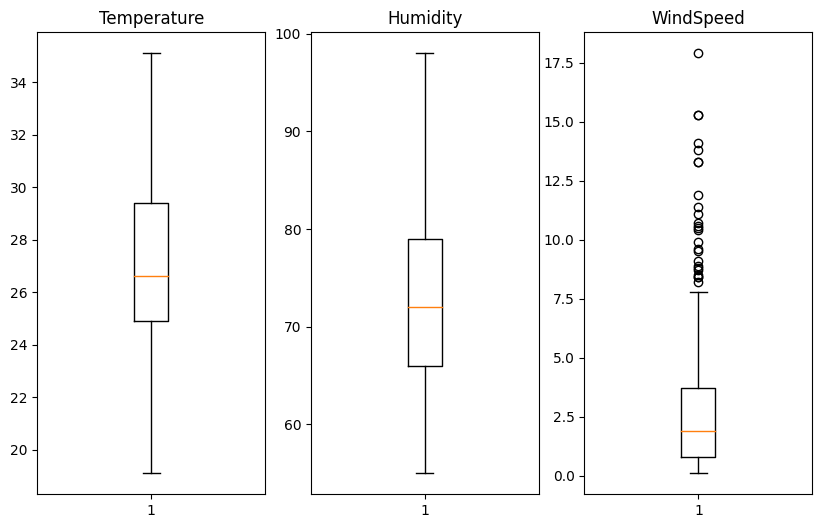

In [ ]:
# Q3 and Q1 on the slide above is incorrect. They're supposed to be the other way around.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(10, 6))

for i, col in enumerate(['Temperature', 'Humidity', 'WindSpeed']):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.show()

In [ ]:
frequency_table = df['Outlook'].value_counts().reset_index()
frequency_table.columns = ['Grade', 'Frequency']

frequency_table

,Grade,Frequency
0,sunny,147
1,overcast,129
2,rainy,89


# **03-03(Types Distribution)**

In [ ]:
golf_dataset = pd.read_csv("/content/drive/MyDrive/PlayGolf?/archive/golf_dataset_weather_tropical_1year.csv")
df = golf_dataset[['Date','Outlook'] + golf_dataset.select_dtypes(include=['number']).columns.tolist()].copy()

df

,Date,Outlook,SunshineDuration,Temperature,Humidity,WindDirection,WindSpeed,Pressure,TotalPlayer,TimePerRound
0,2021-01-01,rainy,1.7,27.2,79,62.0,1.3,1010.3,28,206
1,2021-01-02,sunny,11.8,33.4,70,350.0,0.1,1013.2,74,453
2,2021-01-03,sunny,13.1,31.3,75,345.3,2.2,1005.5,63,290
3,2021-01-04,overcast,0.8,26.8,68,304.2,2.3,1009.6,56,298
4,2021-01-05,sunny,5.1,30.8,59,0.1,6.2,1011.3,70,213
...,...,...,...,...,...,...,...,...,...,...
360,2021-12-27,rainy,2.8,25.0,85,318.9,0.4,1008.1,30,346
361,2021-12-28,rainy,0.3,22.3,71,327.8,0.7,1013.7,26,265
362,2021-12-29,sunny,5.7,29.7,65,343.6,1.9,1010.6,80,442
363,2021-12-30,overcast,4.8,26.8,84,0.6,0.6,1007.5,60,342


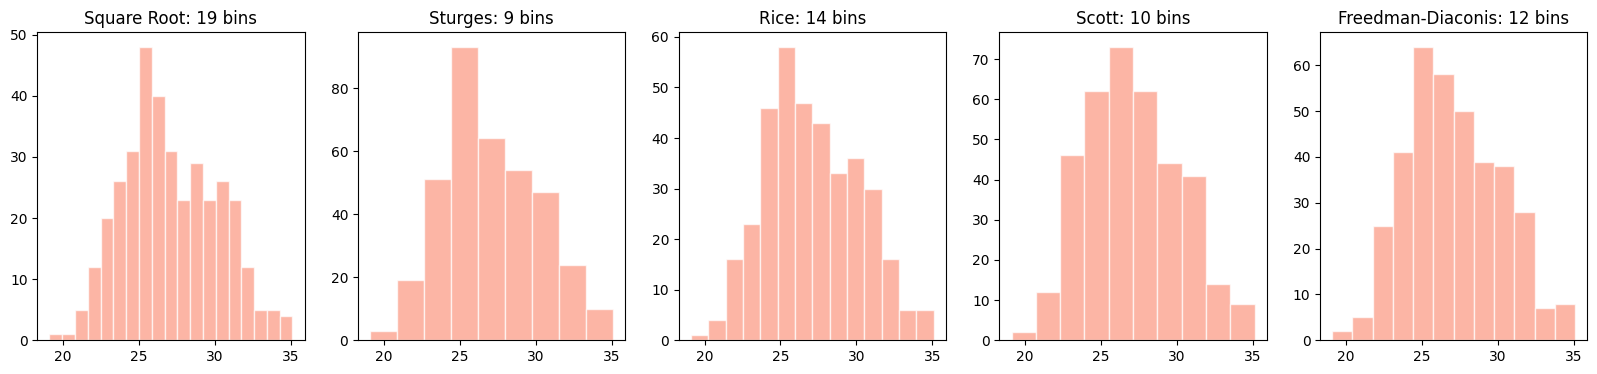

In [ ]:
temp_data = df['Temperature']

# Calculate variables
n = len(temp_data)
std_dev = np.std(temp_data)
IQR = np.percentile(temp_data, 75) - np.percentile(temp_data, 25)

# Calculate bins
bins_dict = {
    "Square Root": int(np.sqrt(n)),
    "Sturges": int(1 + 3.322 * np.log10(n)),
    "Rice": int(2 * n ** (1/3)),
    "Scott": int((max(temp_data) - min(temp_data)) / (3.5 * std_dev / n ** (1/3))),
    "Freedman-Diaconis": int((max(temp_data) - min(temp_data)) / (2 * IQR / n ** (1/3)))
}

# Create the subplots
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Plot histograms
for i, (title, bins) in enumerate(bins_dict.items()):
    axes[i].hist(temp_data, bins=bins, edgecolor='white', color="#FB967F", alpha=0.7)
    axes[i].set_title(f"{title}: {bins} bins")

plt.show()

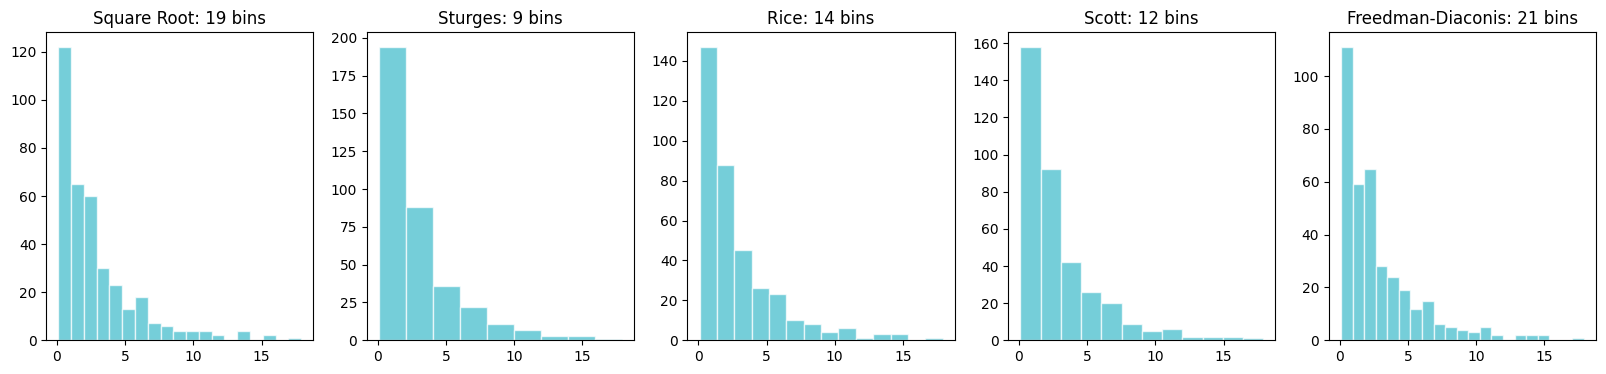

In [ ]:
temp_data = df['WindSpeed']

# Calculate variables
n = len(temp_data)
std_dev = np.std(temp_data)
IQR = np.percentile(temp_data, 75) - np.percentile(temp_data, 25)

# Calculate bins
bins_dict = {
    "Square Root": int(np.sqrt(n)),
    "Sturges": int(1 + 3.322 * np.log10(n)),
    "Rice": int(2 * n ** (1/3)),
    "Scott": int((max(temp_data) - min(temp_data)) / (3.5 * std_dev / n ** (1/3))),
    "Freedman-Diaconis": int((max(temp_data) - min(temp_data)) / (2 * IQR / n ** (1/3)))
}

# Create the subplots
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Plot histograms
for i, (title, bins) in enumerate(bins_dict.items()):
    axes[i].hist(temp_data, bins=bins, edgecolor='white', color="#3BBAC9", alpha=0.7)
    axes[i].set_title(f"{title}: {bins} bins")

plt.show()

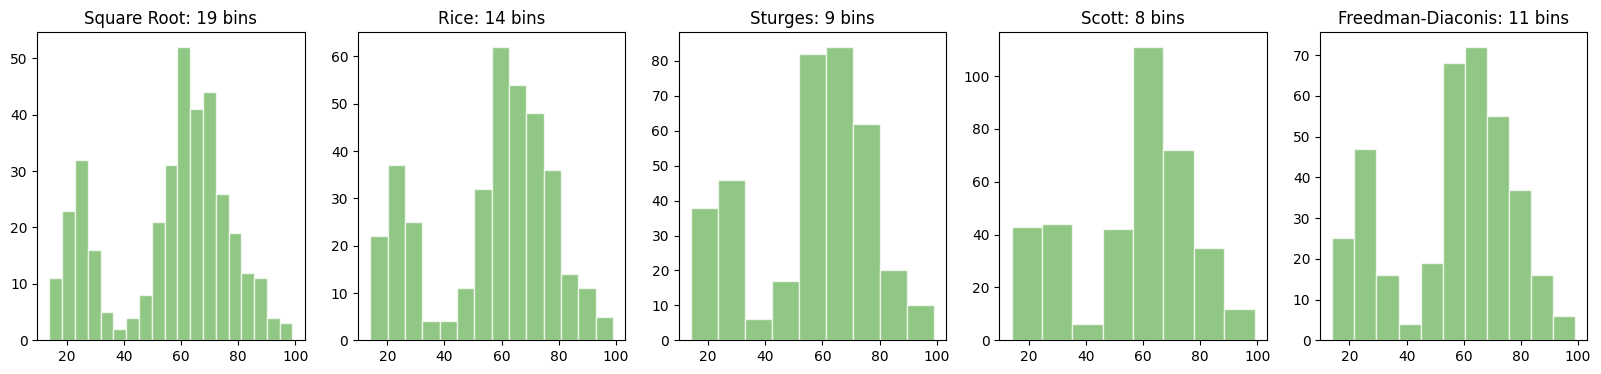

In [ ]:
temp_data = df['TotalPlayer']

# Calculate variables
n = len(temp_data)
std_dev = np.std(temp_data)
IQR = np.percentile(temp_data, 75) - np.percentile(temp_data, 25)
range_data = max(temp_data) - min(temp_data)
n_root = n ** (1/3)

# Calculate bins and combine with titles in a dictionary
bins_dict = {
    "Square Root": int(np.sqrt(n)),
    "Rice": int(2 * n_root),
    "Sturges": int(1 + 3.322 * np.log10(n)),
    "Scott": int(range_data / (3.5 * std_dev / n_root)),
    "Freedman-Diaconis": int(range_data / (2 * IQR / n_root))
}

# Create the subplots
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Plot histograms
for i, (title, bins) in enumerate(bins_dict.items()):
    axes[i].hist(temp_data, bins=bins, edgecolor='white', color="#62B050", alpha=0.7)
    axes[i].set_title(f"{title}: {bins} bins")

plt.show()

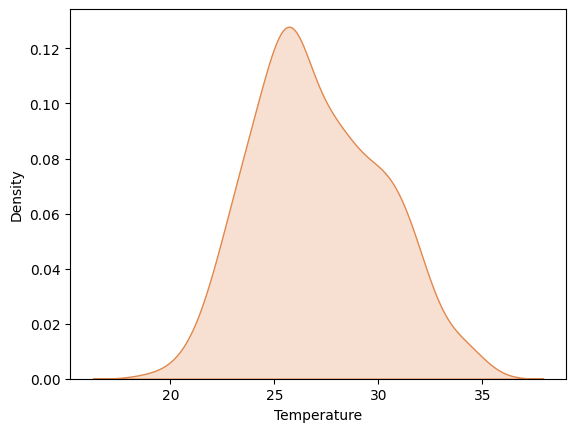

In [ ]:
sns.kdeplot(df['Temperature'], fill=True, color="#E1874C")
plt.show()

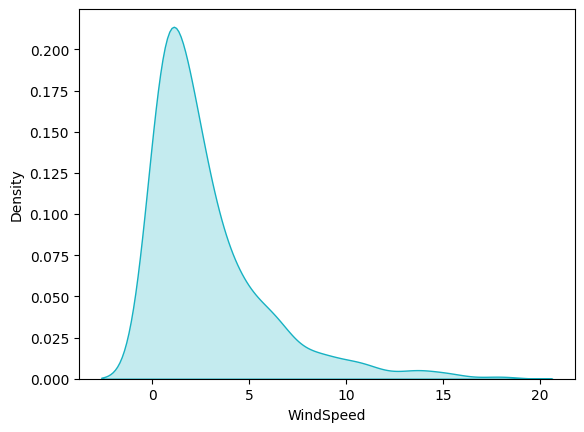

In [ ]:
sns.kdeplot(df['WindSpeed'], fill=True, color="#16B1C2")
plt.show()

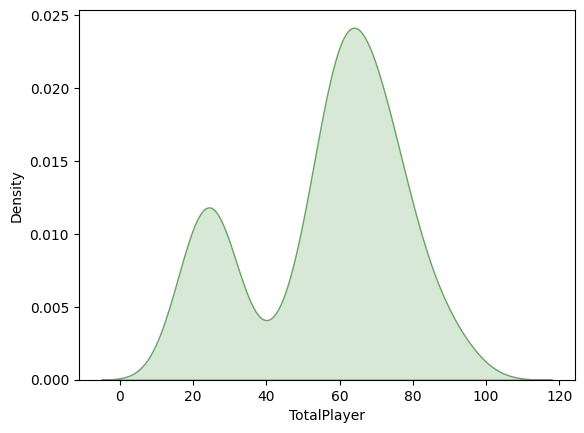

In [ ]:
sns.kdeplot(df['TotalPlayer'], fill=True, color="#63A75E")
plt.show()

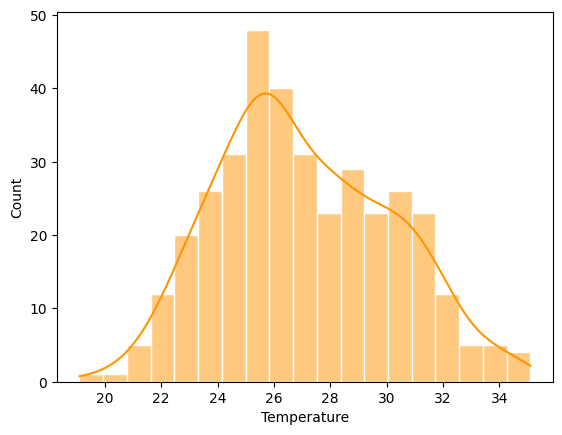

In [ ]:
sns.histplot(df['Temperature'], bins=19, edgecolor='white', kde=True, color="#FF9502")
plt.show()

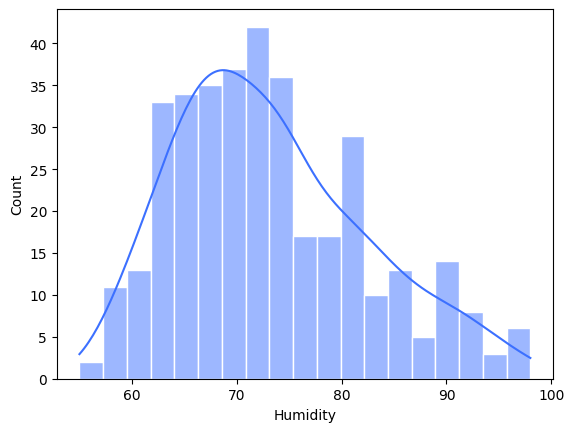

In [ ]:
sns.histplot(df['Humidity'], bins=19, kde=True, edgecolor="white", color="#3C70FF")
plt.show()

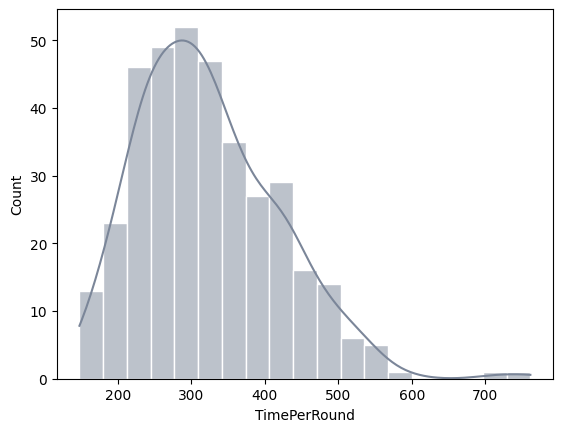

In [ ]:
sns.histplot(df['TimePerRound'], bins=19, kde=True, edgecolor="white", color="#7B8699")
plt.show()

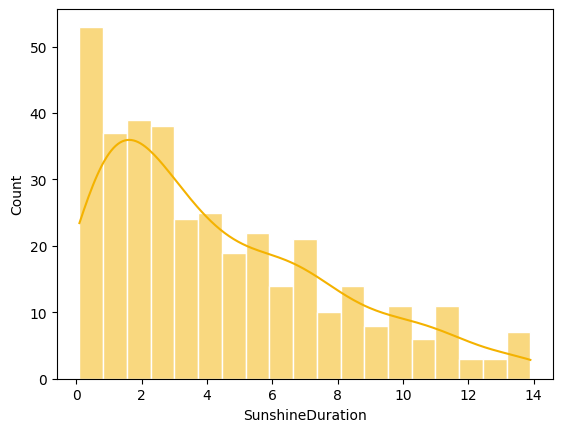

In [ ]:
sns.histplot(df['SunshineDuration'], bins=19, kde=True, color="#f4b200", edgecolor="white")
plt.show()

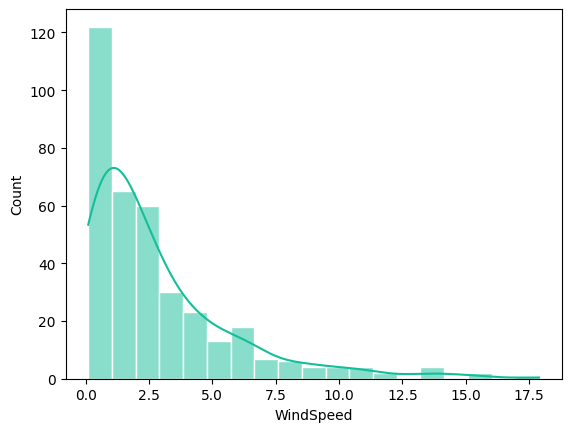

In [ ]:
sns.histplot(df['WindSpeed'], bins=19, kde=True, color="#13be99", edgecolor="white")
plt.show()

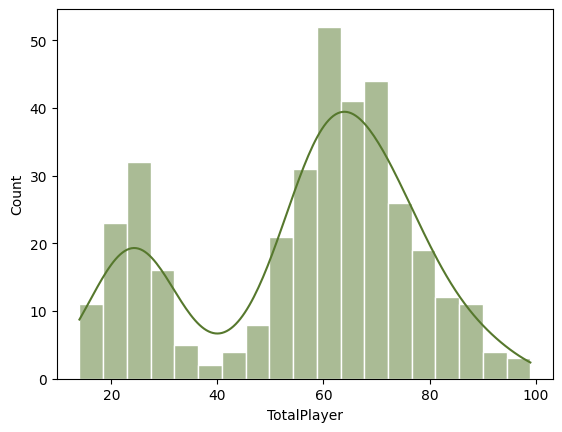

In [ ]:
sns.histplot(df['TotalPlayer'], bins=19, kde=True, color= "#56782D", edgecolor="white")
plt.show()

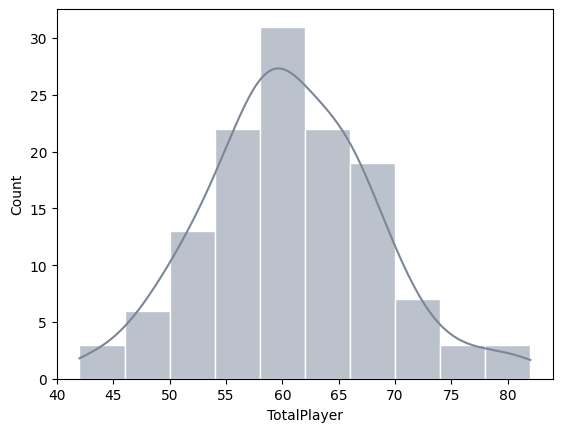

In [ ]:
sns.histplot(df[df['Outlook'] == 'overcast']['TotalPlayer'], bins=10, kde=True, color="#7B8699", edgecolor="white")
plt.show()

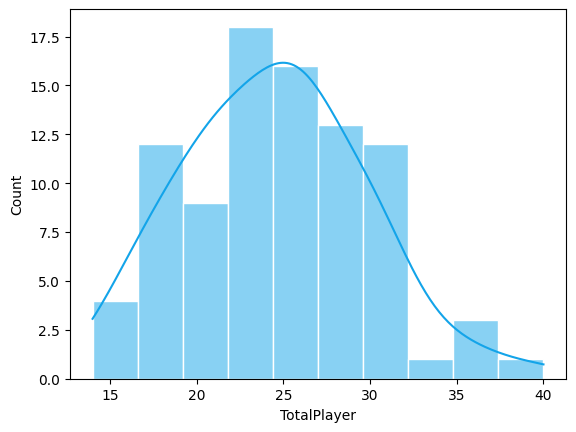

In [ ]:
sns.histplot(df[df['Outlook'] == 'rainy']['TotalPlayer'], bins=10, kde=True, color="#13a4e9", edgecolor="white")
plt.show()

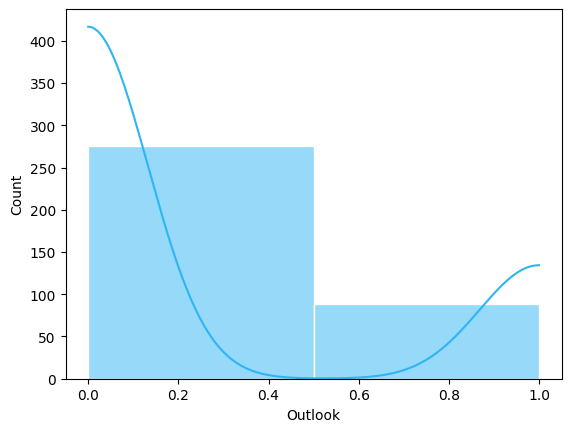

In [ ]:
sns.histplot((df['Outlook'] == 'rainy').astype(int), bins=2, kde=True, color="#2FB5F4", edgecolor="white")
plt.show()

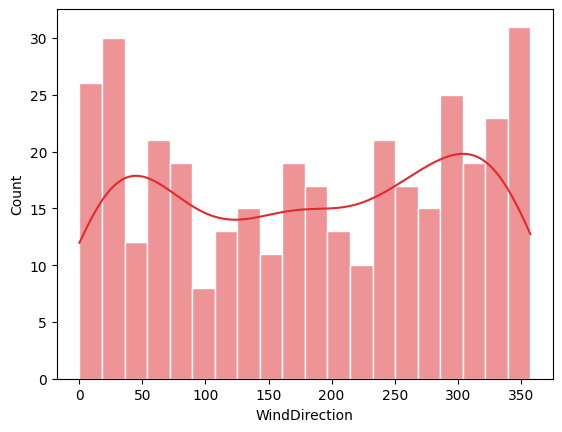

In [ ]:
sns.histplot(df['WindDirection'], bins=20, kde=True, color="#E12A2F", edgecolor="white")
plt.show()

# **03-04(Distribution Fitting)**

In [ ]:
# All codes depend on this cell
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#plt.rcParams['figure.dpi'] = 300
#plt.rcParams["axes.spines.right"] = False
#plt.rcParams["axes.spines.top"] = False
#plt.rcParams["figure.figsize"] = (4.5, 3.5)

golf_dataset = pd.read_csv("/content/drive/MyDrive/PlayGolf?/archive/golf_dataset_weather_tropical_1year.csv")
df = golf_dataset[['Date','Outlook'] + golf_dataset.select_dtypes(include=['number']).columns.tolist()].copy()

df

,Date,Outlook,SunshineDuration,Temperature,Humidity,WindDirection,WindSpeed,Pressure,TotalPlayer,TimePerRound
0,2021-01-01,rainy,1.7,27.2,79,62.0,1.3,1010.3,28,206
1,2021-01-02,sunny,11.8,33.4,70,350.0,0.1,1013.2,74,453
2,2021-01-03,sunny,13.1,31.3,75,345.3,2.2,1005.5,63,290
3,2021-01-04,overcast,0.8,26.8,68,304.2,2.3,1009.6,56,298
4,2021-01-05,sunny,5.1,30.8,59,0.1,6.2,1011.3,70,213
...,...,...,...,...,...,...,...,...,...,...
360,2021-12-27,rainy,2.8,25.0,85,318.9,0.4,1008.1,30,346
361,2021-12-28,rainy,0.3,22.3,71,327.8,0.7,1013.7,26,265
362,2021-12-29,sunny,5.7,29.7,65,343.6,1.9,1010.6,80,442
363,2021-12-30,overcast,4.8,26.8,84,0.6,0.6,1007.5,60,342


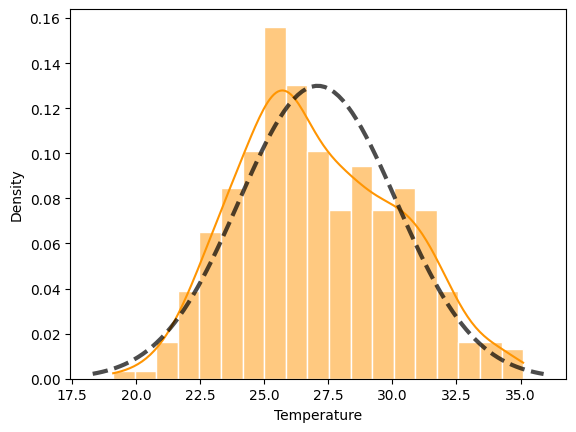

In [ ]:
from scipy.stats import norm

sample_data = df['Temperature']

# Create original plot
sns.histplot(sample_data, bins=19, kde=True,  edgecolor='white', stat="density", color='#FF9502')

# Set range of plot
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

# Fit a normal distribution to the data
mu, std = norm.fit(sample_data)
p_norm = norm.pdf(x, mu, std)
plt.plot(x, p_norm, 'k--', linewidth=3, alpha=0.7)

plt.show()

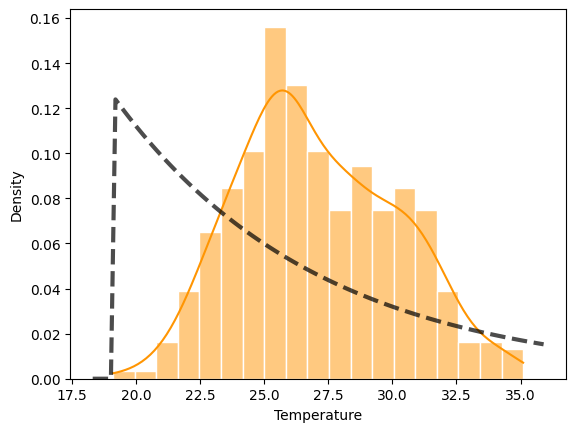

In [ ]:
from scipy.stats import expon

sample_data = df['Temperature']

# Create original plot
sns.histplot(sample_data, bins=19, kde=True,  edgecolor='white', stat="density", color='#FF9502')

# Set range of plot
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

# Fit an exponential distribution to the data
loc_exp, scale_exp = expon.fit(sample_data)
p_exp = expon.pdf(x, loc_exp, scale_exp)
plt.plot(x, p_exp, 'k--', linewidth=3, alpha=0.7)

plt.show()

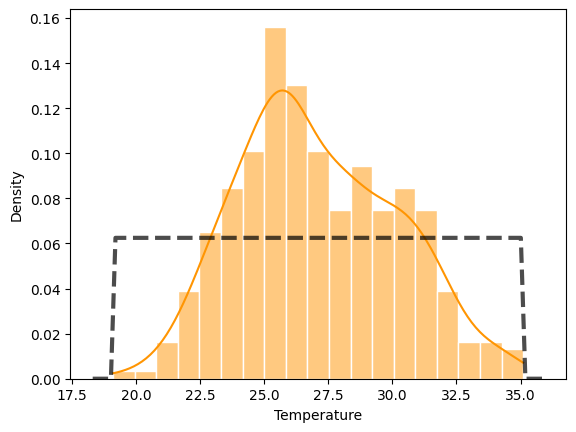

In [ ]:
from scipy.stats import uniform

sample_data = df['Temperature']

# Create original plot
sns.histplot(sample_data, bins=19, kde=True,  edgecolor='white', stat="density", color='#FF9502')

# Set range of plot
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

# Fit a uniform distribution to the data
loc_uni, scale_uni = uniform.fit(sample_data)
p_uniform = uniform.pdf(x, loc_uni, scale_uni)
plt.plot(x, p_uniform, 'k--', linewidth=3, alpha=0.7)

plt.show()

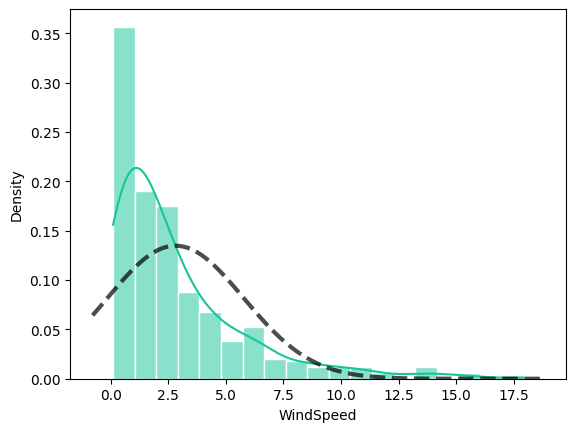

In [ ]:
from scipy.stats import norm

sample_data = df['WindSpeed']

# Create original plot
sns.histplot(sample_data, bins=19, kde=True,  edgecolor='white', stat="density", color='#15C599')

# Set range of plot
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

# Fit a normal distribution to the data
mu, std = norm.fit(sample_data)
p_norm = norm.pdf(x, mu, std)
plt.plot(x, p_norm, 'k--', linewidth=3, alpha=0.7)

plt.show()

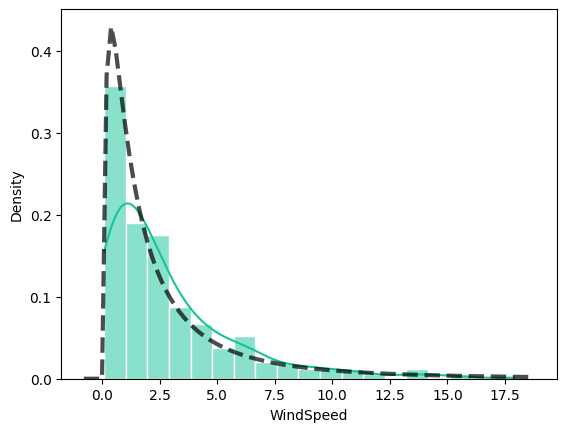

In [ ]:
from scipy.stats import lognorm

sample_data = df['WindSpeed']

# Create original plot
sns.histplot(sample_data, bins=19, kde=True,  edgecolor='white', stat="density", color='#15C599')

# Set range of plot
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

# Fit an exponential distribution to the data
shape, loc, scale = lognorm.fit(sample_data, floc=0)
p_lognorm = lognorm.pdf(x, shape, loc, scale)
plt.plot(x, p_lognorm, 'k--', linewidth=3, alpha=0.7)


plt.show()

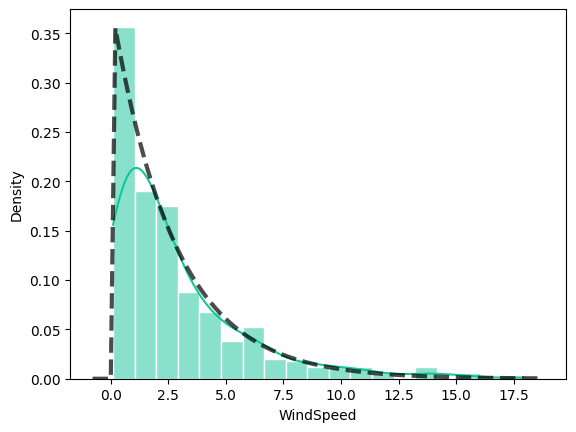

In [ ]:
from scipy.stats import expon

sample_data = df['WindSpeed']

# Create original plot
sns.histplot(sample_data, bins=19, kde=True,  edgecolor='white', stat="density", color='#15C599')

# Set range of plot
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

# Fit an exponential distribution to the data
loc_exp, scale_exp = expon.fit(sample_data)
p_exp = expon.pdf(x, loc_exp, scale_exp)
plt.plot(x, p_exp, 'k--', linewidth=3, alpha=0.7)

plt.show()

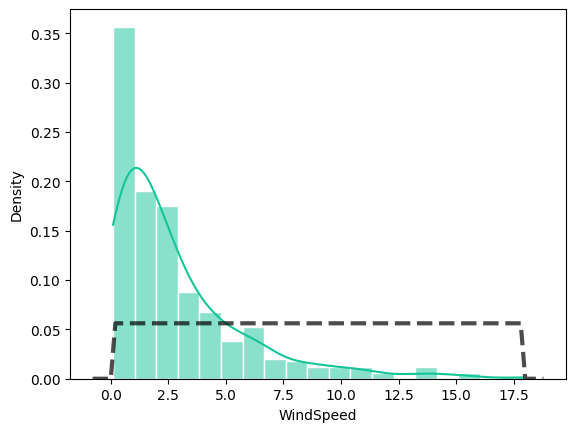

In [ ]:
from scipy.stats import uniform

sample_data = df['WindSpeed']

# Create original plot
sns.histplot(sample_data, bins=19, kde=True,  edgecolor='white', stat="density", color='#15C599')

# Set range of plot
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

# Fit a uniform distribution to the data
loc_uni, scale_uni = uniform.fit(sample_data)
p_uniform = uniform.pdf(x, loc_uni, scale_uni)
plt.plot(x, p_uniform, 'k--', linewidth=3, alpha=0.7)

plt.show()

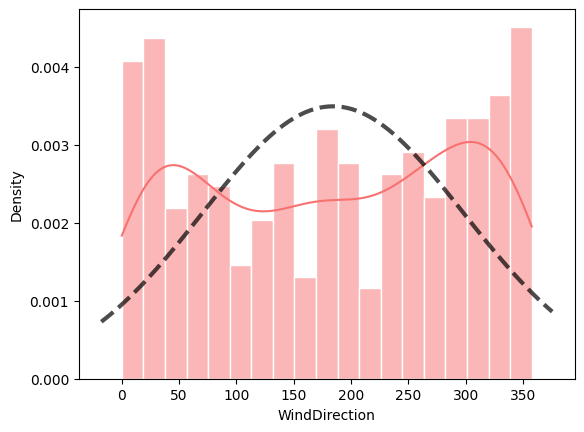

In [ ]:
from scipy.stats import norm

sample_data = df['WindDirection']

# Create original plot
sns.histplot(sample_data, bins=19, kde=True,  edgecolor='white', stat="density", color='#F87171')

# Set range of plot
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

# Fit a normal distribution to the data
mu, std = norm.fit(sample_data)
p_norm = norm.pdf(x, mu, std)
plt.plot(x, p_norm, 'k--', linewidth=3, alpha=0.7)

plt.show()

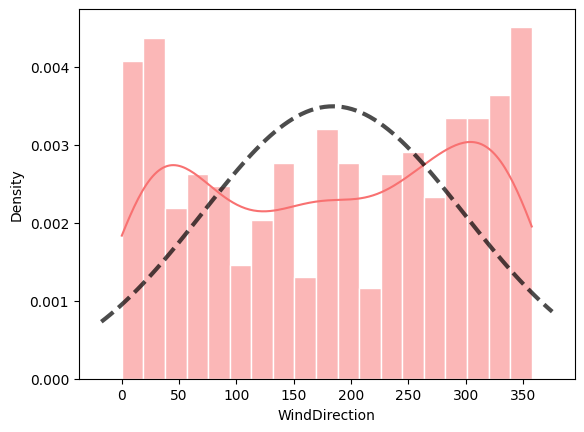

In [ ]:
from scipy.stats import lognorm

sample_data = df['WindDirection']
sample_data = sample_data[sample_data > 0]
# Create original plot
sns.histplot(sample_data, bins=19, kde=True,  edgecolor='white', stat="density", color='#F87171')
# Set range of plot
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

# Fit a log-normal distribution to the data
shape, loc, scale = lognorm.fit(sample_data)
p_lognorm = lognorm.pdf(x, shape, loc, scale)
plt.plot(x, p_lognorm, 'k--', linewidth=3, alpha=0.7)

plt.show()

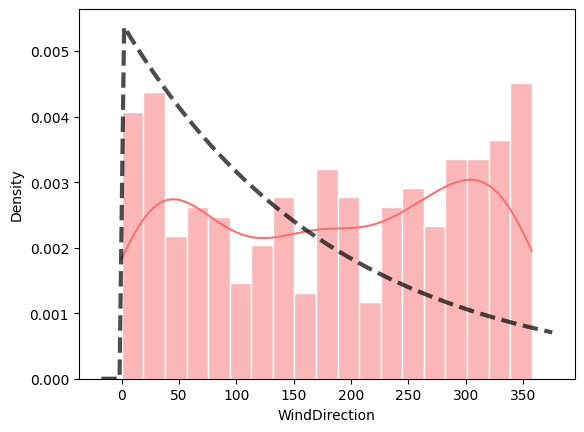

In [ ]:
from scipy.stats import uniform

sample_data = df['WindDirection']

# Create original plot
sns.histplot(sample_data, bins=19, kde=True,  edgecolor='white', stat="density", color='#F87171')
# Set range of plot
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

# Fit an exponential distribution to the data
loc_exp, scale_exp = expon.fit(sample_data)
p_exp = expon.pdf(x, loc_exp, scale_exp)
plt.plot(x, p_exp, 'k--', linewidth=3, alpha=0.7)

plt.show()

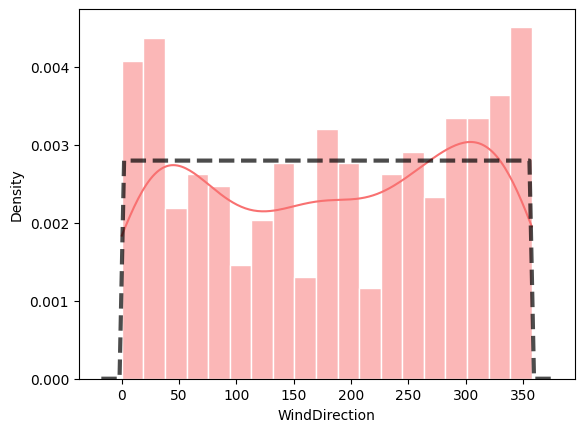

In [ ]:
from scipy.stats import uniform

sample_data = df['WindDirection']

# Create original plot
sns.histplot(sample_data, bins=19, kde=True,  edgecolor='white', stat="density", color='#F87171')
# Set range of plot
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

# Fit a uniform distribution to the data
loc_uni, scale_uni = uniform.fit(sample_data)
p_uniform = uniform.pdf(x, loc_uni, scale_uni)
plt.plot(x, p_uniform, 'k--', linewidth=3, alpha=0.7)

plt.show()

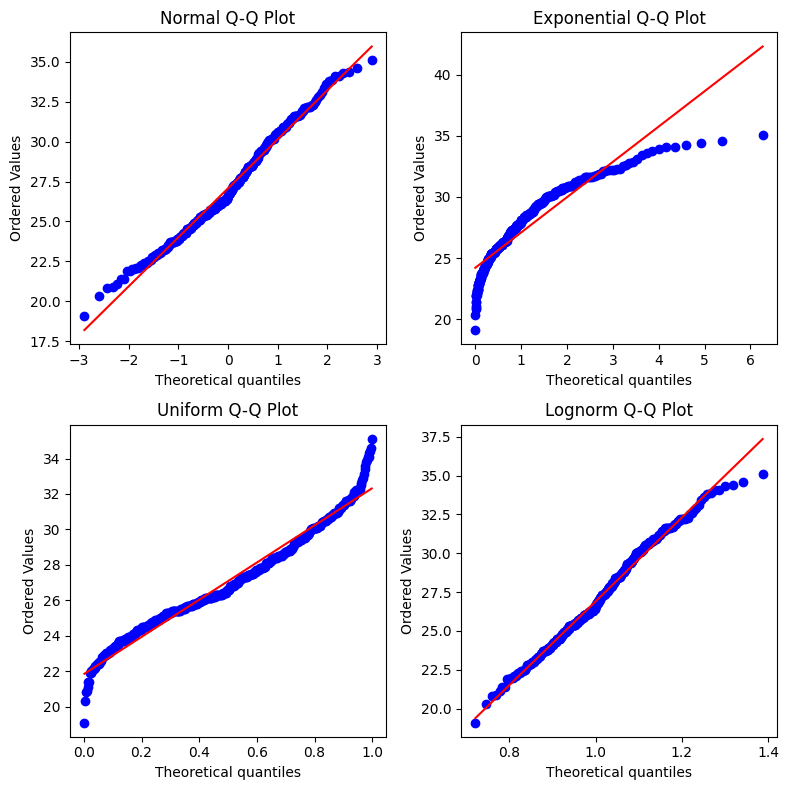

In [ ]:
from scipy.stats import probplot, norm, expon, uniform, lognorm

sample_data = df['Temperature']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

# Normal Q-Q plot
probplot(sample_data, plot=axes[0, 0], dist="norm", fit=True)
axes[0, 0].set_title("Normal Q-Q Plot")

# Exponential Q-Q plot
probplot(sample_data, plot=axes[0, 1], dist="expon", fit=True)
axes[0, 1].set_title("Exponential Q-Q Plot")

# Uniform Q-Q plot
probplot(sample_data, plot=axes[1, 0], dist="uniform", fit=True)
axes[1, 0].set_title("Uniform Q-Q Plot")

# Lognorm Q-Q plot
shape_lognorm, _, _ = lognorm.fit(sample_data, floc=0)
probplot(sample_data, plot=axes[1, 1], dist="lognorm", sparams=(shape_lognorm,), fit=True)
axes[1, 1].set_title("Lognorm Q-Q Plot")

plt.tight_layout()
plt.show()

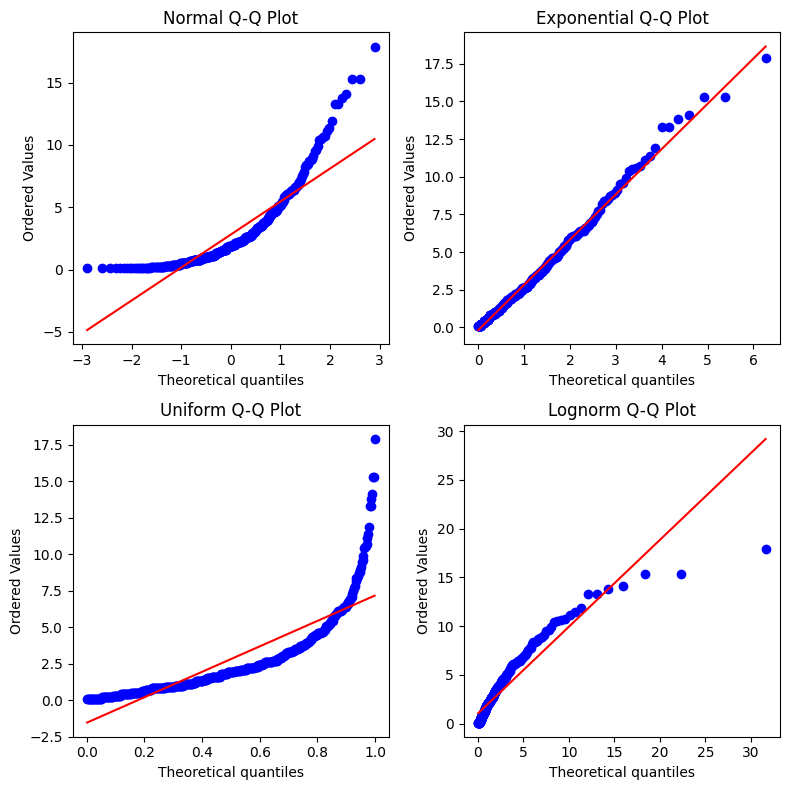

In [ ]:
from scipy.stats import probplot, norm, expon, uniform, lognorm

sample_data = df['WindSpeed']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

# Normal Q-Q plot
probplot(sample_data, plot=axes[0, 0], dist="norm", fit=True)
axes[0, 0].set_title("Normal Q-Q Plot")

# Exponential Q-Q plot
probplot(sample_data, plot=axes[0, 1], dist="expon", fit=True)
axes[0, 1].set_title("Exponential Q-Q Plot")

# Uniform Q-Q plot
probplot(sample_data, plot=axes[1, 0], dist="uniform", fit=True)
axes[1, 0].set_title("Uniform Q-Q Plot")

# Lognorm Q-Q plot
shape_lognorm, _, _ = lognorm.fit(sample_data, floc=0)
probplot(sample_data, plot=axes[1, 1], dist="lognorm", sparams=(shape_lognorm,), fit=True)
axes[1, 1].set_title("Lognorm Q-Q Plot")

plt.tight_layout()
plt.show()

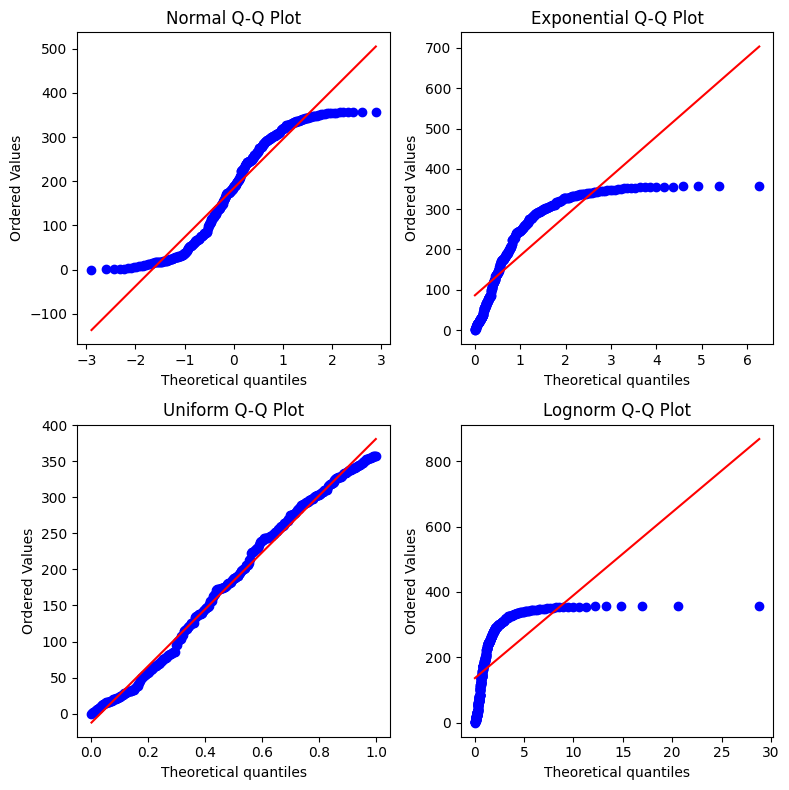

In [ ]:
from scipy.stats import probplot, norm, expon, uniform, lognorm

sample_data = df['WindDirection']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

# Normal Q-Q plot
probplot(sample_data, plot=axes[0, 0], dist="norm", fit=True)
axes[0, 0].set_title("Normal Q-Q Plot")

# Exponential Q-Q plot
probplot(sample_data, plot=axes[0, 1], dist="expon", fit=True)
axes[0, 1].set_title("Exponential Q-Q Plot")

# Uniform Q-Q plot
probplot(sample_data, plot=axes[1, 0], dist="uniform", fit=True)
axes[1, 0].set_title("Uniform Q-Q Plot")

# Lognorm Q-Q plot
shape_lognorm, _, _ = lognorm.fit(sample_data, floc=0)
probplot(sample_data, plot=axes[1, 1], dist="lognorm", sparams=(shape_lognorm,), fit=True)
axes[1, 1].set_title("Lognorm Q-Q Plot")

plt.tight_layout()
plt.show()

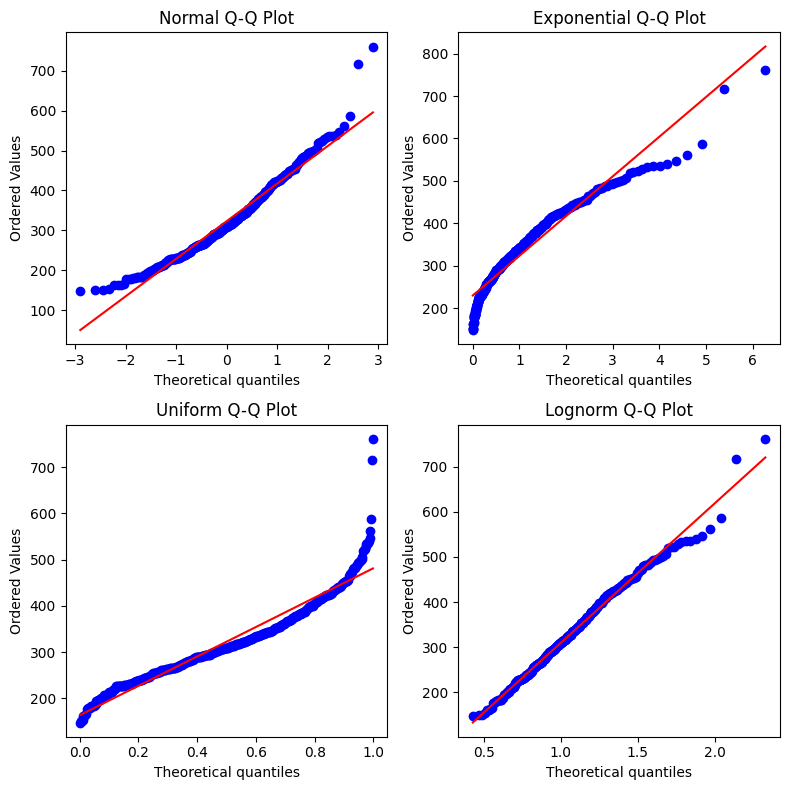

In [ ]:
from scipy.stats import probplot, norm, expon, uniform, lognorm

sample_data = df['TimePerRound']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

# Normal Q-Q plot
probplot(sample_data, plot=axes[0, 0], dist="norm", fit=True)
axes[0, 0].set_title("Normal Q-Q Plot")

# Exponential Q-Q plot
probplot(sample_data, plot=axes[0, 1], dist="expon", fit=True)
axes[0, 1].set_title("Exponential Q-Q Plot")

# Uniform Q-Q plot
probplot(sample_data, plot=axes[1, 0], dist="uniform", fit=True)
axes[1, 0].set_title("Uniform Q-Q Plot")

# Lognorm Q-Q plot
shape_lognorm, _, _ = lognorm.fit(sample_data, floc=0)
probplot(sample_data, plot=axes[1, 1], dist="lognorm", sparams=(shape_lognorm,), fit=True)
axes[1, 1].set_title("Lognorm Q-Q Plot")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from scipy import stats

# Columns to test and distributions to compare against
df_test = df.copy()
columns_to_test = ['SunshineDuration', 'Temperature', 'Humidity', 'WindDirection', 'WindSpeed', 'TimePerRound']
distributions_to_test = ['norm', 'lognorm', 'expon', 'uniform']

# Initialize a DataFrame to store p-values
results_df = pd.DataFrame(index=columns_to_test, columns=distributions_to_test)

# Test each column against each distribution
for col in columns_to_test:
    sample_data = df_test[col]

    for dist_name in distributions_to_test:
        params = getattr(stats, dist_name).fit(sample_data)
        ks_statistic, ks_p_value = stats.kstest(sample_data, dist_name, args=params)
        results_df.loc[col, dist_name] = ks_p_value

results_df.T

,SunshineDuration,Temperature,Humidity,WindDirection,WindSpeed,TimePerRound
norm,0.000044,0.01148,0.004633,0.001103,0.0,0.069723
lognorm,0.048698,0.140261,0.488995,0.001103,0.141833,0.935856
expon,0.135475,0.0,0.0,0.0,0.153768,0.0
uniform,0.0,0.0,0.0,0.032761,0.0,0.0


# **03-05(Bivariete Analysis)**

In [ ]:
# All codes depend on this cell
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#plt.rcParams['figure.dpi'] = 300
#plt.rcParams["axes.spines.right"] = False
#plt.rcParams["axes.spines.top"] = False
#plt.rcParams["figure.figsize"] = (4.5, 3.5)

golf_dataset = pd.read_csv("/content/drive/MyDrive/PlayGolf?/archive/golf_dataset_weather_tropical_1year.csv")
df = golf_dataset[['Date','Outlook'] + golf_dataset.select_dtypes(include=['number']).columns.tolist()].copy()

df

,Date,Outlook,SunshineDuration,Temperature,Humidity,WindDirection,WindSpeed,Pressure,TotalPlayer,TimePerRound
0,2021-01-01,rainy,1.7,27.2,79,62.0,1.3,1010.3,28,206
1,2021-01-02,sunny,11.8,33.4,70,350.0,0.1,1013.2,74,453
2,2021-01-03,sunny,13.1,31.3,75,345.3,2.2,1005.5,63,290
3,2021-01-04,overcast,0.8,26.8,68,304.2,2.3,1009.6,56,298
4,2021-01-05,sunny,5.1,30.8,59,0.1,6.2,1011.3,70,213
...,...,...,...,...,...,...,...,...,...,...
360,2021-12-27,rainy,2.8,25.0,85,318.9,0.4,1008.1,30,346
361,2021-12-28,rainy,0.3,22.3,71,327.8,0.7,1013.7,26,265
362,2021-12-29,sunny,5.7,29.7,65,343.6,1.9,1010.6,80,442
363,2021-12-30,overcast,4.8,26.8,84,0.6,0.6,1007.5,60,342


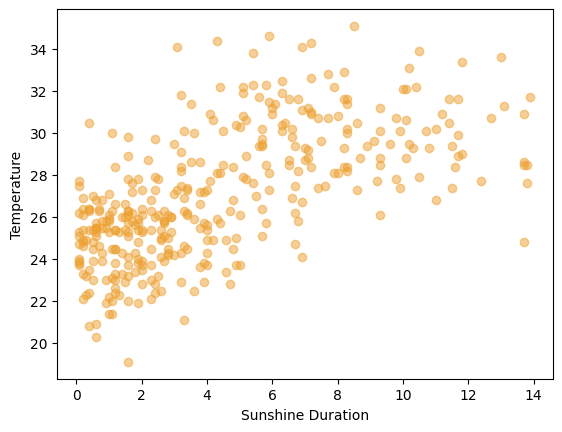

In [ ]:
plt.scatter(df['SunshineDuration'], df['Temperature'], color = "#EDA131", alpha=0.5)
plt.xlabel('Sunshine Duration')
plt.ylabel('Temperature')
plt.show()

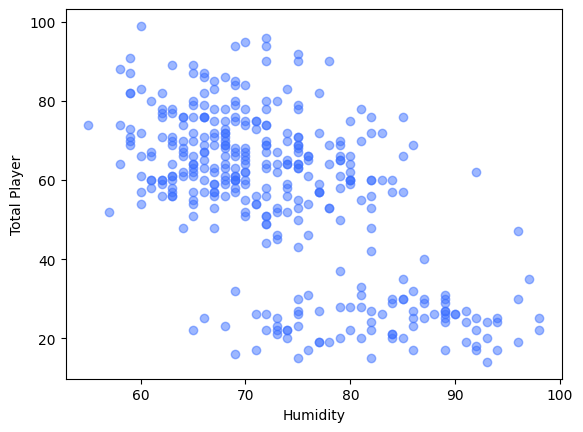

In [ ]:
plt.scatter(df['Humidity'], df['TotalPlayer'], color = "#3C70FF", alpha=0.5)
plt.xlabel('Humidity')
plt.ylabel('Total Player')
plt.show()

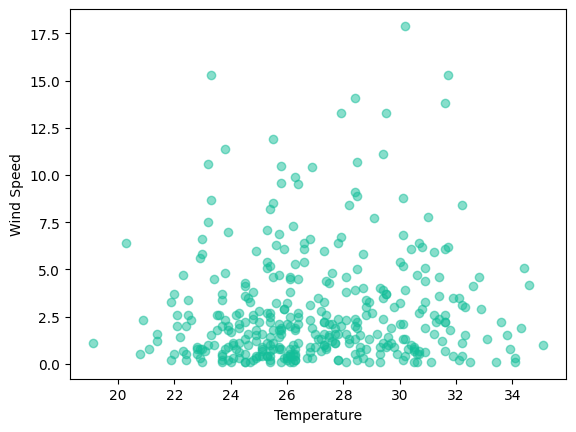

In [ ]:
plt.scatter(df['Temperature'], df['WindSpeed'], color = "#13be99", alpha=0.5)
plt.xlabel('Temperature')
plt.ylabel('Wind Speed')
plt.show()

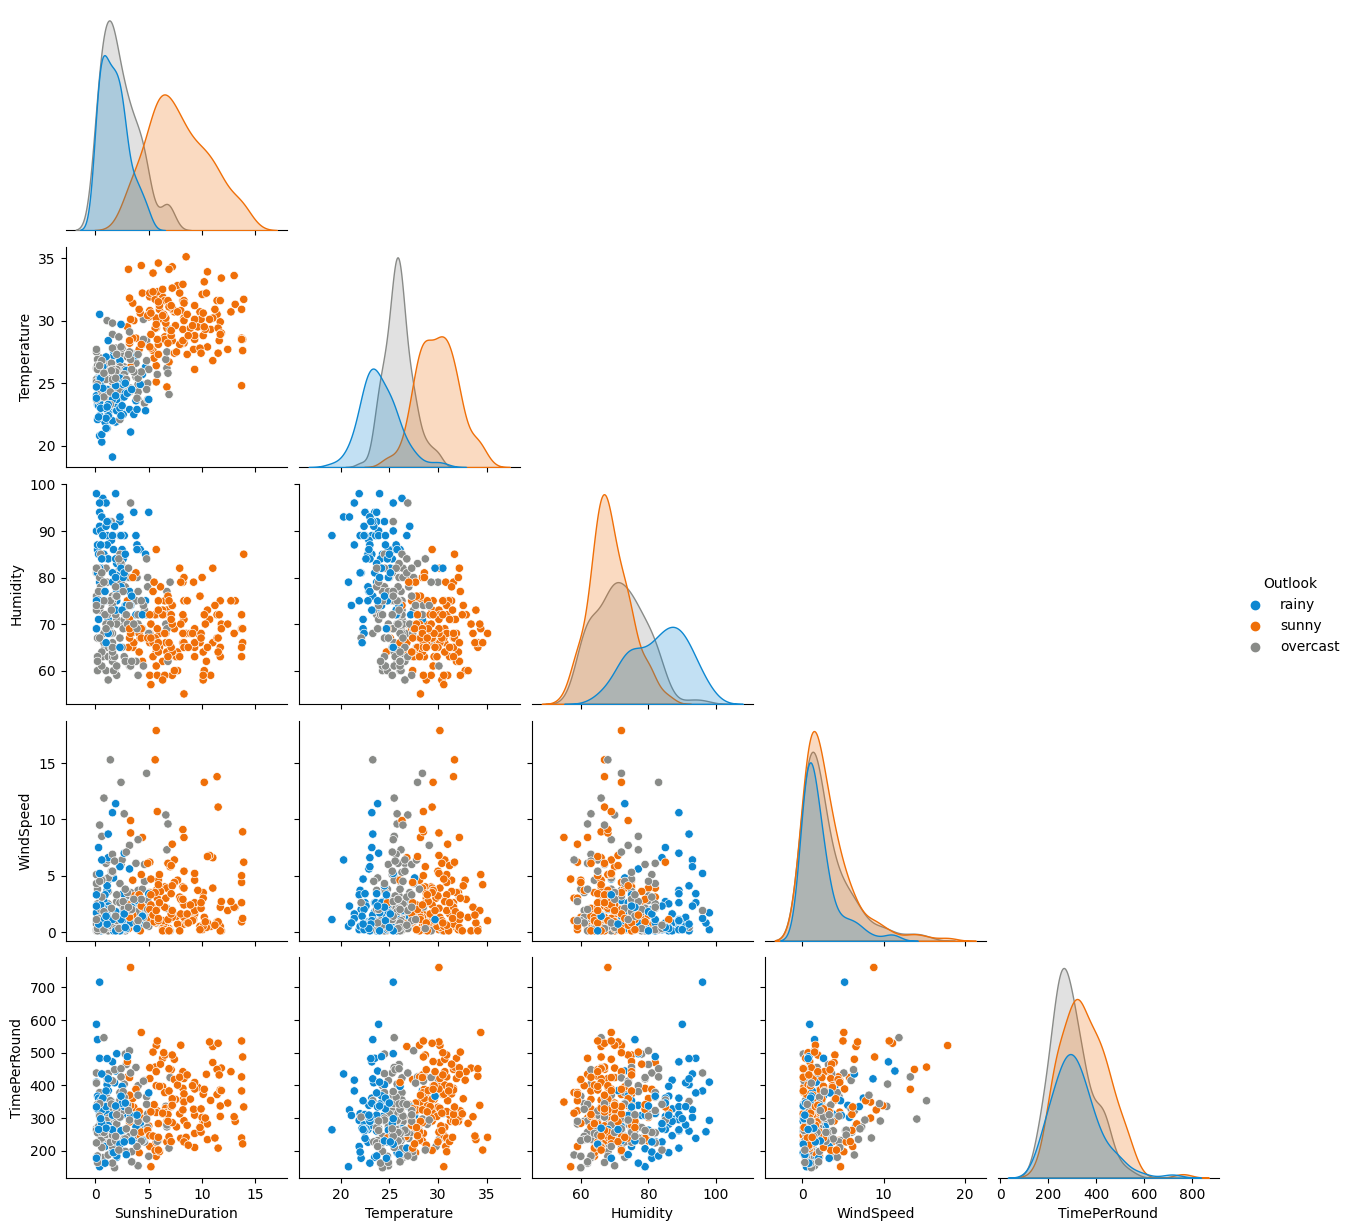

In [ ]:
# This is a scatter matrix, not correlation matrix
selected_columns = df[['SunshineDuration', 'Temperature', 'Humidity', 'WindSpeed', 'TimePerRound','Outlook']]
weather_palette = {'sunny': '#EF6F08', 'overcast': '#898B88','rainy':'#0D87D1'}
sns.pairplot(selected_columns, corner=True, hue='Outlook', palette=weather_palette)
plt.show()

In [ ]:
df[['SunshineDuration','Temperature']].corr().iloc[0, 1].round(2)

0.63

In [ ]:
df[['Humidity','TotalPlayer']].corr().iloc[0, 1].round(2)

-0.61

In [ ]:
df[['Temperature','WindSpeed']].corr().iloc[0, 1].round(2)

0.08

In [ ]:
selected_columns = df[['SunshineDuration', 'Temperature', 'Humidity', 'WindSpeed', 'TotalPlayer', 'TimePerRound']]
correlation_matrix = selected_columns.corr().round(2)

correlation_matrix

,SunshineDuration,Temperature,Humidity,WindSpeed,TotalPlayer,TimePerRound
SunshineDuration,1.00,0.63,-0.36,0.08,0.52,0.19
Temperature,0.63,1.00,-0.44,0.08,0.65,0.22
Humidity,-0.36,-0.44,1.00,-0.13,-0.61,0.11
WindSpeed,0.08,0.08,-0.13,1.00,0.12,0.27
TotalPlayer,0.52,0.65,-0.61,0.12,1.00,0.20
TimePerRound,0.19,0.22,0.11,0.27,0.20,1.00


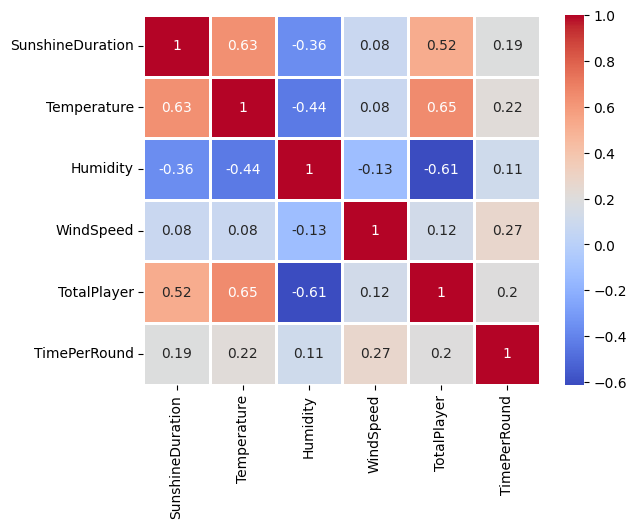

In [ ]:
selected_columns = df[['SunshineDuration', 'Temperature', 'Humidity', 'WindSpeed', 'TotalPlayer', 'TimePerRound']]
correlation_matrix = selected_columns.corr().round(2)

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidth=1)
plt.show()

In [ ]:
df['TemperatureCategory'] = pd.qcut(df['Temperature'], q=3, labels=['Low', 'Medium', 'High'])
cross_tab = pd.crosstab(df['Outlook'], df['TemperatureCategory'])

cross_tab

TemperatureCategory,Low,Medium,High
Outlook,,,
overcast,46,75,8
rainy,73,14,2
sunny,3,34,110


In [ ]:
from scipy.stats import chi2_contingency

df['TemperatureCategory'] = pd.qcut(df['Temperature'], q=3, labels=['Low', 'Medium', 'High'])
contingency_table = pd.crosstab(df['Outlook'], df['TemperatureCategory'])

chi2, p_value, _, expected = chi2_contingency(contingency_table)

print(f"Chi-Square value: {chi2}")
print(f"P-value: {p_value}")
print(f"Expected Frequencies Table: \n{expected.round(0)}")

Chi-Square value: 274.67781286218235
P-value: 3.1290688890772704e-58
Expected Frequencies Table: 
[[43. 43. 42.]
 [30. 30. 29.]
 [49. 50. 48.]]


In [ ]:
# Calculate minimum degree of freedom (Run chi2 code first)
df_min = min(contingency_table.shape) - 1

# Calculate Cramer's V
cramers_v = np.sqrt(chi2 / (len(df) * df_min))

print(f"Cramer's V\n{cramers_v.round(3)}")

Cramer's V
0.613


In [ ]:
df['TemperatureCategory'] = pd.qcut(df['Temperature'], q=3, labels=['Low', 'Medium', 'High'])
df['HumidityCategory'] = pd.qcut(df['Humidity'], q=3, labels=['Low', 'Medium', 'High'])
df['WindSpeedCategory'] = pd.qcut(df['Humidity'], q=4, labels=['Low', 'Medium', 'Medium-High', 'High'])

cat_cols = ['Outlook', 'TemperatureCategory', 'HumidityCategory', 'WindSpeedCategory']
cramers_df = pd.DataFrame(index=cat_cols, columns=cat_cols)

def cramers_v(x, y):
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = len(x)
    return np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_df.loc[col1, col2] = cramers_v(df[col1], df[col2]).round(2)

cramers_df

,Outlook,TemperatureCategory,HumidityCategory,WindSpeedCategory
Outlook,1.0,0.61,0.4,0.44
TemperatureCategory,0.61,1.0,0.31,0.3
HumidityCategory,0.4,0.31,1.0,0.8
WindSpeedCategory,0.44,0.3,0.8,1.0


In [ ]:
pivot_table_result = pd.pivot_table(df,
                                    values=['Temperature', 'Humidity', 'WindSpeed'],
                                    index=['Outlook'],
                                    aggfunc='mean')  # You can change 'mean' to other functions like 'sum', 'max', etc.

pivot_table_result

,Humidity,Temperature,WindSpeed
Outlook,,,
overcast,71.596899,25.947287,2.982171
rainy,83.134831,23.997753,2.097753
sunny,68.659864,29.940816,3.097279


# **Playground**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/PlayGolf?/archive/golf_dataset_long_format_with_text.csv')
df

,Date,Weekday,Holiday,Month,Season,Temperature,Humidity,Windy,Outlook,Crowdedness,EmailCampaign,MaintenanceTask,ID,Play,PlayTimeHour,Review
0,2021-01-01,4,1,Jan,Winter,3.3,49.0,1,sunny,0.73,Happy New Year and welcome to the Golf Course!...,"['Cleaning Amenities', 'Restroom Cleaning']",A,1,3.1,Absolutely exhilarating first day of the year!...
1,2021-01-01,4,1,Jan,Winter,3.3,49.0,1,sunny,0.73,Happy New Year and welcome to the Golf Course!...,"['Cleaning Amenities', 'Restroom Cleaning']",B,0,0.0,NaN
2,2021-01-01,4,1,Jan,Winter,3.3,49.0,1,sunny,0.73,Happy New Year and welcome to the Golf Course!...,"['Cleaning Amenities', 'Restroom Cleaning']",C,0,0.0,NaN
3,2021-01-01,4,1,Jan,Winter,3.3,49.0,1,sunny,0.73,Happy New Year and welcome to the Golf Course!...,"['Cleaning Amenities', 'Restroom Cleaning']",D,1,3.6,"Ah, the exhilarating dance with the wind today..."
4,2021-01-01,4,1,Jan,Winter,3.3,49.0,1,sunny,0.73,Happy New Year and welcome to the Golf Course!...,"['Cleaning Amenities', 'Restroom Cleaning']",E,1,3.4,The atmosphere on the course was nothing short...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7660,2023-12-31,6,0,Dec,Winter,1.8,43.0,0,snow,0.57,Bid adieu to 2023 with a snowy swing! It’s 1.8...,['Snow Cleaning'],C,0,0.0,NaN
7661,2023-12-31,6,0,Dec,Winter,1.8,43.0,0,snow,0.57,Bid adieu to 2023 with a snowy swing! It’s 1.8...,['Snow Cleaning'],D,0,0.0,NaN
7662,2023-12-31,6,0,Dec,Winter,1.8,43.0,0,snow,0.57,Bid adieu to 2023 with a snowy swing! It’s 1.8...,['Snow Cleaning'],E,0,0.0,NaN
7663,2023-12-31,6,0,Dec,Winter,1.8,43.0,0,snow,0.57,Bid adieu to 2023 with a snowy swing! It’s 1.8...,['Snow Cleaning'],F,1,3.3,Happy New Year to me! The golf course blankete...


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/PlayGolf?/archive/golf_dataset_wide_format.csv')
df

,Date,Weekday,Month,Season,Holiday,Temperature,Humidity,Windy,Outlook,Crowdedness,...,Play_C,PlayTimeHour_C,Play_D,PlayTimeHour_D,Play_E,PlayTimeHour_E,Play_F,PlayTimeHour_F,Play_G,PlayTimeHour_G
0,2021-01-01,4,Jan,Winter,1,3.3,49.0,1,sunny,0.73,...,0,0.0,1,3.6,1,3.4,0,0.0,0,0.0
1,2021-01-02,5,Jan,Winter,0,2.9,53.0,0,sunny,0.74,...,1,4.6,0,0.0,0,0.0,0,0.0,0,0.0
2,2021-01-03,6,Jan,Winter,0,2.3,58.0,0,overcast,0.70,...,1,4.6,0,0.0,0,0.0,0,0.0,0,0.0
3,2021-01-04,0,Jan,Winter,0,3.0,45.0,0,overcast,0.61,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
4,2021-01-05,1,Jan,Winter,0,3.1,31.0,1,sunny,0.52,...,0,0.0,0,0.0,1,2.8,0,0.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,2023-12-27,2,Dec,Winter,0,7.1,48.0,1,sunny,0.60,...,0,0.0,0,0.0,1,3.2,0,0.0,0,0.0
1091,2023-12-28,3,Dec,Winter,0,6.6,55.0,0,overcast,0.60,...,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0
1092,2023-12-29,4,Dec,Winter,0,6.3,30.0,1,overcast,0.67,...,0,0.0,1,3.7,1,2.8,0,0.0,0,0.0
1093,2023-12-30,5,Dec,Winter,0,4.3,54.0,1,overcast,0.68,...,0,0.0,1,3.7,0,0.0,0,0.0,0,0.0


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/PlayGolf?/archive/golf_dataset_the_origin.csv')
df

,Outlook,Temperature,Humidity,Wind,Play
0,sunny,85.0,85.0,0,0
1,sunny,80.0,90.0,1,0
2,overcast,83.0,78.0,0,1
3,rain,70.0,96.0,0,1
4,rain,68.0,80.0,0,1
5,rain,65.0,70.0,1,0
6,overcast,64.0,65.0,1,1
7,sunny,72.0,95.0,0,0
8,sunny,69.0,70.0,0,1
9,rain,75.0,80.0,0,1


# **OPTIONAL**

In [ ]:
# @title Informasi Data
print("Informasi Umum tentang Dataframe:")
print(df.info())

print("\nJumlah Baris dan Kolom:")
print(df.shape)

print("\nTipe Data Kolom:")
print(df.dtypes)

print("\nStatistik Ringkas:")
print(df.describe())

print("\nBeberapa Baris Pertama:")
print(df.head())

print("\nBeberapa Baris Terakhir:")
print(df.tail())

In [ ]:
print(df.describe())
print(df['Outlook'].value_counts())
print(df['Wind'].value_counts())

       Temperature   Humidity       Wind       Play  AirQualityIndex  \
count    13.000000  13.000000  13.000000  13.000000        13.000000   
mean     73.250000  79.076923   0.384615   0.692308        77.038462   
std       6.533567  11.198672   0.506370   0.480384         6.878292   
min      64.000000  64.000000   0.000000   0.000000        64.500000   
25%      69.000000  70.000000   0.000000   0.000000        72.500000   
50%      72.000000  78.000000   0.000000   1.000000        78.000000   
75%      75.000000  90.000000   1.000000   1.000000        83.000000   
max      85.000000  96.000000   1.000000   1.000000        85.000000   

       Outlook_overcast  Outlook_rain  Outlook_sunny  Temperature_zscore  \
count         13.000000     13.000000      13.000000           13.000000   
mean           0.307692      0.307692       0.384615           -0.000769   
std            0.480384      0.480384       0.506370            1.039411   
min            0.000000      0.000000       0.0

# **Split Data**

In [ ]:
X = df[['Outlook', 'Temperature', 'Humidity', 'Wind']]
y = df['Play']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# **Decission Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Definisikan arsitektur hyperparameter
hyperparameters = {
    'criterion': 'entropy',  # atau 'entropy'
    'splitter': 'best',  # atau 'random'
    'max_depth': None,    # atau angka tertentu
    'min_samples_split': 10,  # atau angka tertentu
    'min_samples_leaf': 1   # atau angka tertentu
}

# Buat model Decision Tree dengan hyperparameter yang telah ditentukan
clf = DecisionTreeClassifier(**hyperparameters)

# Latih model pada data latih
clf.fit(X_train, y_train)

# Lakukan prediksi pada data uji
y_pred = clf.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)
print("Akurasi: {:.2f}%".format(accuracy * 100))

# Tampilkan laporan klasifikasi
print("Laporan Klasifikasi:\n", classification_report(y_test, y_pred))

# Tampilkan matriks kebingungan
print("Matriks Kebingungan:\n", confusion_matrix(y_test, y_pred))



Akurasi: 75.00%
Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.75      1.00      0.86         3

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4

Matriks Kebingungan:
 [[0 1]
 [0 3]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Buat model Decision Tree
clf = DecisionTreeClassifier()

# Definisikan rentang parameter yang akan diuji
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Buat objek GridSearchCV
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy')

# Latih model dengan parameter terbaik yang ditemukan
grid_search.fit(X_train, y_train)

# Parameter terbaik
best_params = grid_search.best_params_
print("Parameter Terbaik:", best_params)

# Akurasi terbaik
best_accuracy = grid_search.best_score_
print("Akurasi Terbaik: {:.2f}%".format(best_accuracy * 100))

# Gunakan model dengan parameter terbaik pada data uji
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)
print("Akurasi pada Data Uji: {:.2f}%".format(accuracy * 100))


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Parameter Terbaik: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Akurasi Terbaik: 70.00%
Akurasi pada Data Uji: 75.00%
